# LLM Comparison — GPT-OSS-120B vs Llama-3.3-70B vs Qwen-3-80B: Tool vs Train Mode

**Models:**
- `openai/gpt-oss-120b` (mxfp4) on `gpu33` via vLLM
- `Llama-3.3-70B-Instruct-FP8` on `gpu31` via vLLM
- `Qwen/Qwen3-Next-80B-A3B-Thinking-FP8` (served as `Qwen-3-80B`) on `gpu33` via vLLM  
  ↳ Thinking model — ~13–14k internal reasoning tokens per call; `max_model_len=32000`

**Temperature:** 0.3 · **Dataset:** `main` (appeal + claims + CPA), `exp_config=3`  
**TRAIN set:** 95 EPO Board of Appeal decisions  
**Ground truth:** `train_data_Inv_Step.pkl` — Reversed → Yes, Affirmed → No

### Modes
- **Tool mode** — LLM answers ADM questions using case data only (no ground truth)
- **Train mode** — LLM also receives the *Decision Reasons* + *Order* in the system prompt (oracle guidance)

### Experiment Matrix (13 runs × 2 modes × 3 models = 78 total)

| ADM Config | default | lenient | strict |
|---|---|---|---|
| both | ✓ | ✓ | ✓ |
| sub_adm_1 | ✓ | ✓ | ✓ |
| sub_adm_2 | ✓ | ✓ | ✓ |
| none | ✓ | ✓ | ✓ |
| **+ 1 baseline** (mode-independent) | | |

### Notes on Qwen
- Final verdict context is trimmed to ≤4 000 tokens (vs 20 000 for GPT/Llama) to ensure sufficient output budget
- Per-case wall time ~4× slower than Llama due to thinking overhead (~62 s/case vs ~16 s)

In [24]:
import json, os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from matplotlib.patches import Patch

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (14, 6)

BASE = '/users/sgdbareh/scratch/ADM_JURIX'
PKL  = os.path.join(BASE, 'Data', 'train_data_Inv_Step.pkl')

# ── Model output directories ─────────────────────────────────────────────────
# Each entry: (model_label, tool_dir, train_dir)
# Set dir to None if results are not yet available
MODELS = {
    'GPT':   {
        'tool':  os.path.join(BASE, 'Outputs', 'GPT_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'GPT_TRAIN_MODE'),
    },
    'Llama': {
        'tool':  os.path.join(BASE, 'Outputs', 'LLAMA_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'LLAMA_TRAIN_MODE'),
    },
    'Qwen':  {
        'tool':  os.path.join(BASE, 'Outputs', 'QWEN_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'QWEN_TRAIN_MODE'),
    },
}

Q_COLORS = {'default': '#2196F3', 'lenient': '#4CAF50', 'strict': '#F44336'}
MODE_COLORS  = {'tool': '#FF9800', 'train': '#9C27B0', 'baseline': '#607D8B'}
MODEL_COLORS = {'GPT': '#1565C0', 'Llama': '#2E7D32', 'Qwen': '#B71C1C'}
# Combined: (model, src) → colour for fine-grained charts
COMBO_COLORS = {
    ('GPT',   'tool'):  '#42A5F5',
    ('GPT',   'train'): '#7B1FA2',
    ('Llama', 'tool'):  '#FF7043',
    ('Llama', 'train'): '#388E3C',
    ('Qwen',  'tool'):  '#EF5350',
    ('Qwen',  'train'): '#C62828',
    ('GPT',   'baseline'): '#607D8B',
    ('Llama', 'baseline'): '#90A4AE',
    ('Qwen',  'baseline'): '#B0BEC5',
}

## 1. Ground Truth

In [25]:
gt_df = pd.read_pickle(PKL)
gt_map = gt_df.set_index('Reference')['Outcome'].map(
    {'Reversed': 'Yes', 'Affirmed': 'No'}
).to_dict()

train_cases = sorted(d for d in os.listdir(os.path.join(BASE, 'Data', 'TRAIN'))
                     if os.path.isdir(os.path.join(BASE, 'Data', 'TRAIN', d)))
gt_train = {c: gt_map.get(c, 'MISSING') for c in train_cases}

yes_count = sum(1 for v in gt_train.values() if v == 'Yes')
no_count  = sum(1 for v in gt_train.values() if v == 'No')
missing   = sum(1 for v in gt_train.values() if v == 'MISSING')
print(f'TRAIN cases: {len(train_cases)}')
print(f'Class balance: {yes_count} Yes (Reversed), {no_count} No (Affirmed), {missing} missing')
print(f'Majority-class baseline: {max(yes_count, no_count)/len(train_cases):.1%}')

TRAIN cases: 95
Class balance: 53 Yes (Reversed), 42 No (Affirmed), 0 missing
Majority-class baseline: 55.8%


## 2. Load All Predictions & Metrics (Tool + Train)

In [ ]:
def load_preds(out_dir, src_label):
    """Load all experiment predictions from an output directory.

    Picks the newest matching results file per experiment directory.
    For TRAIN source baseline dirs, prefer train_baseline result files.
    """
    preds = {}
    for exp_name in sorted(os.listdir(out_dir)):
        exp_dir = os.path.join(out_dir, exp_name)
        if not os.path.isdir(exp_dir):
            continue

        result_files = glob.glob(os.path.join(exp_dir, 'results_*.json'))
        if not result_files:
            continue

        chosen = None
        if src_label == 'train' and 'baseline' in exp_name:
            train_bl = [p for p in result_files if 'train_baseline' in os.path.basename(p)]
            if train_bl:
                chosen = max(train_bl, key=os.path.getmtime)

        if chosen is None:
            chosen = max(result_files, key=os.path.getmtime)

        with open(chosen) as f:
            data = json.load(f)
        preds[exp_name] = data.get('run_1', {})
    return preds

def compute_metrics(preds, gt):
    tp = fp = fn = tn = 0
    for cid, pred in preds.items():
        truth = gt.get(cid)
        if not truth or truth == 'MISSING' or pred not in ('Yes', 'No'):
            continue
        if   pred == 'Yes' and truth == 'Yes': tp += 1
        elif pred == 'Yes' and truth == 'No':  fp += 1
        elif pred == 'No'  and truth == 'Yes': fn += 1
        else:                                  tn += 1
    tot = tp + fp + fn + tn
    acc  = (tp + tn) / tot if tot else 0
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec  = tp / (tp + fn) if (tp + fn) else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                tp=tp, fp=fp, fn=fn, tn=tn, n=tot)

def parse_exp_name(name):
    """Return (run_mode, adm_config, questions) from an experiment directory name."""
    parts = name.split('_')
    run_mode = parts[0]                              # tool / train / baseline
    q_type   = parts[-1]                             # default / lenient / strict
    adm_cfg  = '_'.join(parts[1:-1]) if len(parts) > 2 else parts[1]
    return run_mode, adm_cfg, q_type

# ── Load all available model × source combinations ───────────────────────────
all_preds = {}   # (model, src) → preds dict
rows = []

for model_label, dirs in MODELS.items():
    for src_label, src_dir in dirs.items():
        if not src_dir or not os.path.isdir(src_dir):
            print(f'[SKIP] {model_label} {src_label}: {src_dir} not found')
            continue
        preds = load_preds(src_dir, src_label)
        all_preds[(model_label, src_label)] = preds
        print(f'[OK]   {model_label} {src_label}: {len(preds)} experiments from {src_dir}')

        timing_path = os.path.join(src_dir, 'timing.csv')
        timing_df = pd.read_csv(timing_path) if os.path.exists(timing_path) else pd.DataFrame()

        for exp_name, exp_preds in preds.items():
            m = compute_metrics(exp_preds, gt_train)
            run_mode, adm_cfg, q_type = parse_exp_name(exp_name)
            dur = None
            if not timing_df.empty:
                t = timing_df[timing_df['experiment'] == exp_name]
                if len(t): dur = t.iloc[0]['duration_s']
            rows.append(dict(model=model_label, experiment=exp_name, src=src_label,
                             run_mode=run_mode, adm_config=adm_cfg, questions=q_type,
                             duration_s=dur, **m))

metrics = pd.DataFrame(rows)
# Canonical key to join tool↔train across configs (strip leading mode prefix)
metrics['config_key'] = metrics['experiment'].str.replace(r'^(tool|train)_', '', regex=True)
metrics = metrics.sort_values(['model', 'config_key', 'src']).reset_index(drop=True)

print(f'\nTotal rows in metrics table: {len(metrics)}')
print(metrics.groupby(['model', 'src'])['experiment'].count().rename('experiments').to_string())

[OK]   GPT tool: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/GPT_TRAIN
[OK]   GPT train: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/GPT_TRAIN_MODE
[OK]   Llama tool: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/LLAMA_TRAIN
[OK]   Llama train: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/LLAMA_TRAIN_MODE
[OK]   Qwen tool: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/QWEN_TRAIN
[OK]   Qwen train: 13 experiments from /users/sgdbareh/scratch/ADM_JURIX/Outputs/QWEN_TRAIN_MODE

Total rows in metrics table: 78
model  src  
GPT    tool     13
       train    13
Llama  tool     13
       train    13
Qwen   tool     13
       train    13


## 3. Full Metrics Table

In [27]:
show = ['model','experiment','src','adm_config','questions','n',
        'accuracy','precision','recall','f1','tp','fp','fn','tn','duration_s']
metrics[show].style.format({
    'accuracy':'{:.1%}','precision':'{:.2f}','recall':'{:.2f}','f1':'{:.2f}',
    'duration_s':'{:.0f}'
}).background_gradient(subset=['f1'], cmap='RdYlGn', vmin=0, vmax=1)

,model,experiment,src,adm_config,questions,n,accuracy,precision,recall,f1,tp,fp,fn,tn,duration_s
0,GPT,baseline_default,tool,default,default,95,60.0%,0.80,0.38,0.51,20,5,33,37,160
1,GPT,baseline_default,train,default,default,95,62.1%,0.87,0.38,0.53,20,3,33,39,164
2,GPT,tool_both_default,tool,both,default,95,57.9%,0.61,0.66,0.64,35,22,18,20,3295
3,GPT,train_both_default,train,both,default,95,94.7%,1.00,0.91,0.95,48,0,5,42,3271
4,GPT,tool_both_lenient,tool,both,lenient,95,51.6%,0.67,0.26,0.38,14,7,39,35,3586
5,GPT,train_both_lenient,train,both,lenient,95,83.2%,0.89,0.79,0.84,42,5,11,37,3317
6,GPT,tool_both_strict,tool,both,strict,95,53.7%,0.66,0.36,0.46,19,10,34,32,3708
7,GPT,train_both_strict,train,both,strict,95,74.7%,1.00,0.55,0.71,29,0,24,42,3093
8,GPT,tool_none_default,tool,none,default,95,60.0%,0.69,0.51,0.59,27,12,26,30,577
9,GPT,train_none_default,train,none,default,95,88.4%,1.00,0.79,0.88,42,0,11,42,580


## 4. Train vs Tool — Side-by-Side F1 & Accuracy (per model)

Paired bar chart: for each ADM config × question combination, compare tool vs train within each model, and compare models side-by-side.

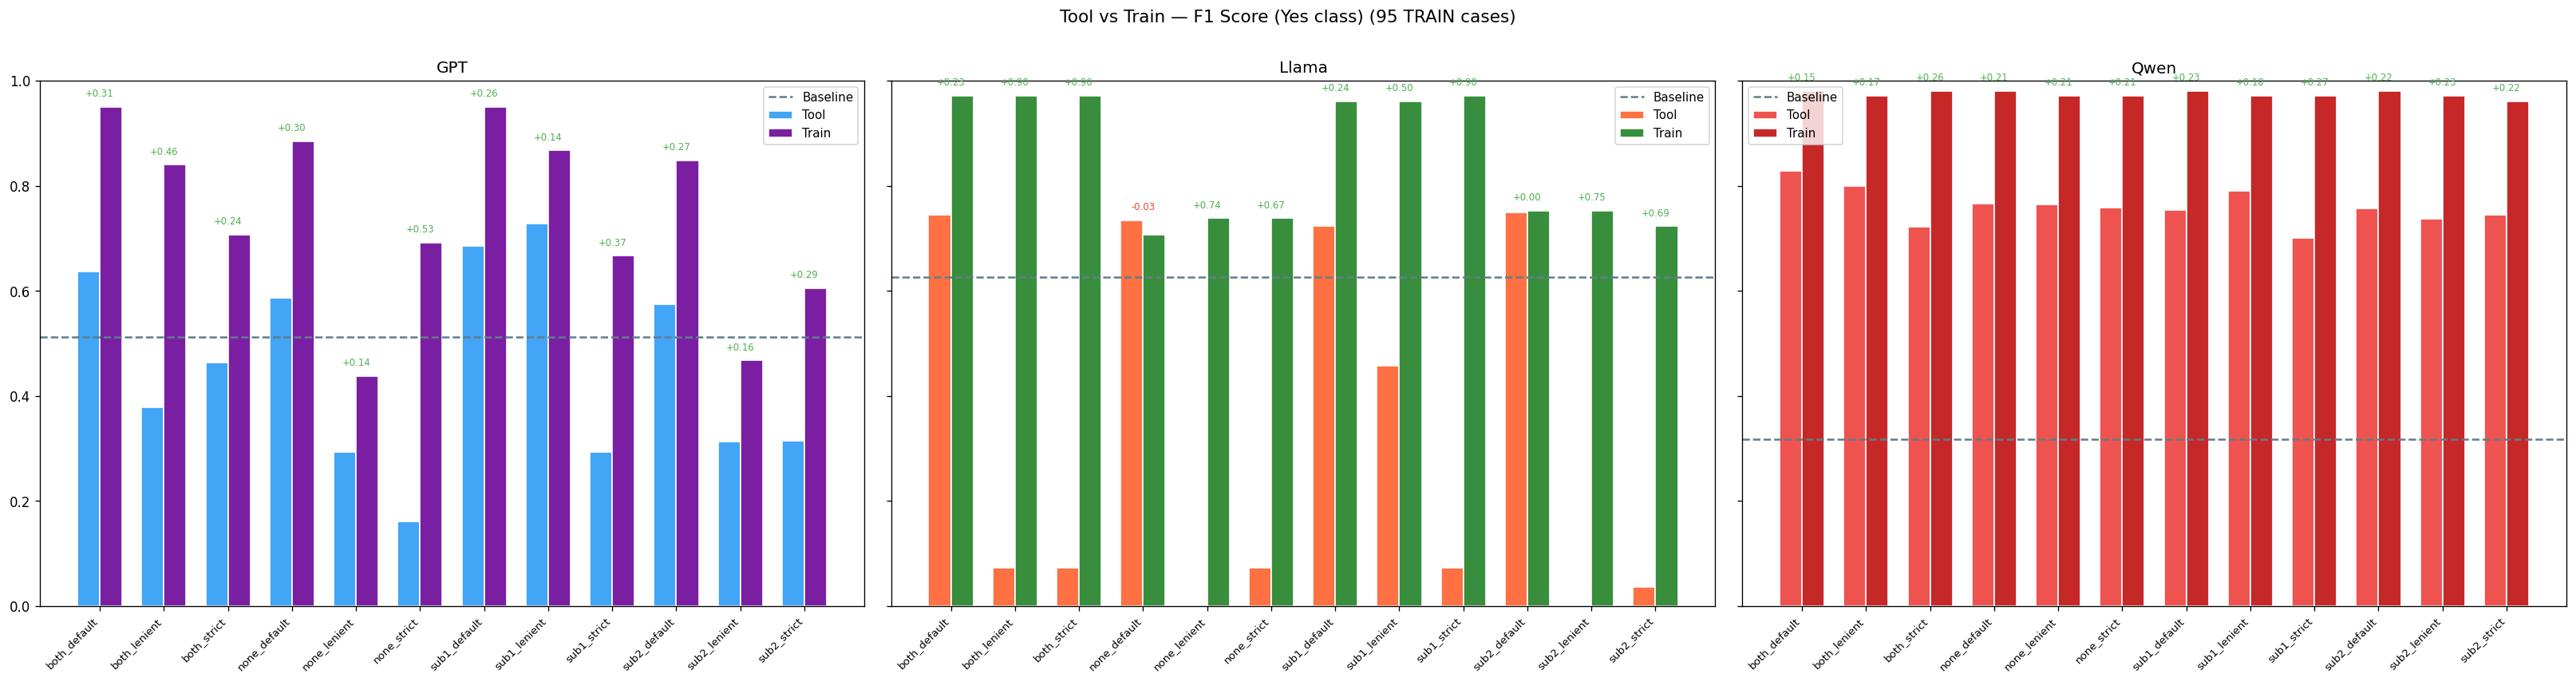

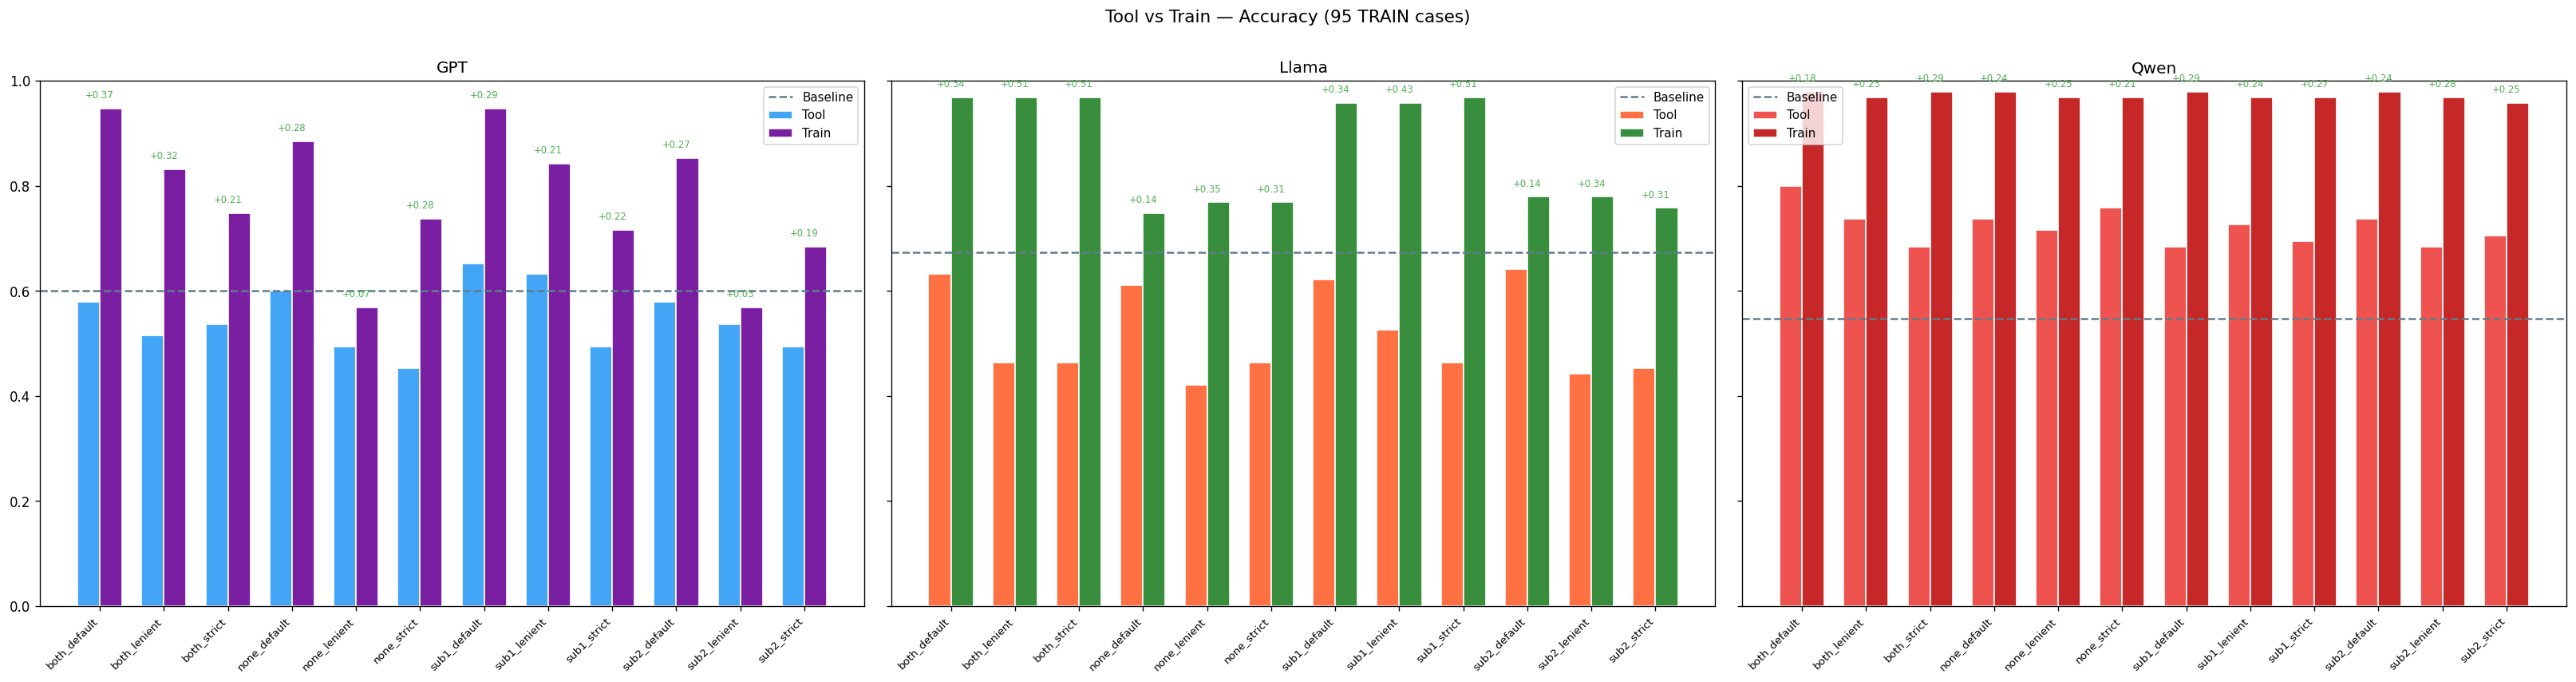

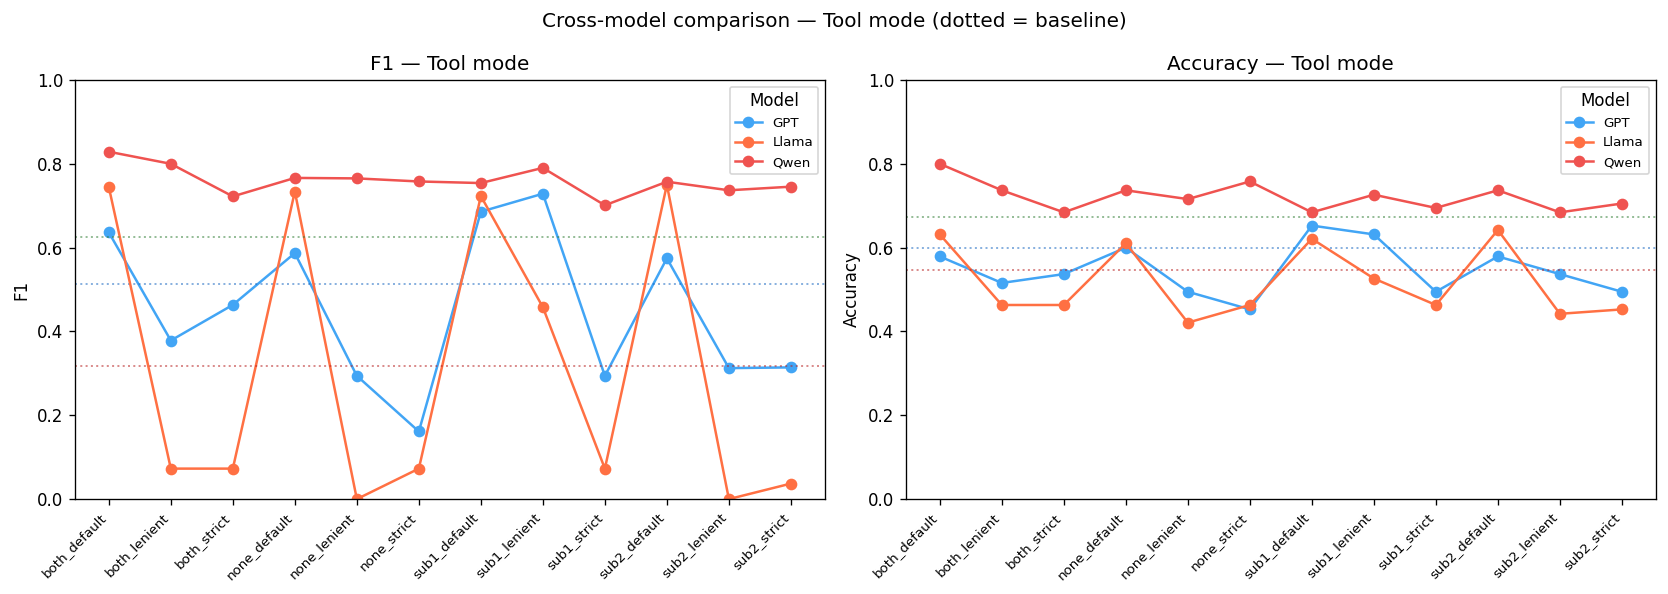

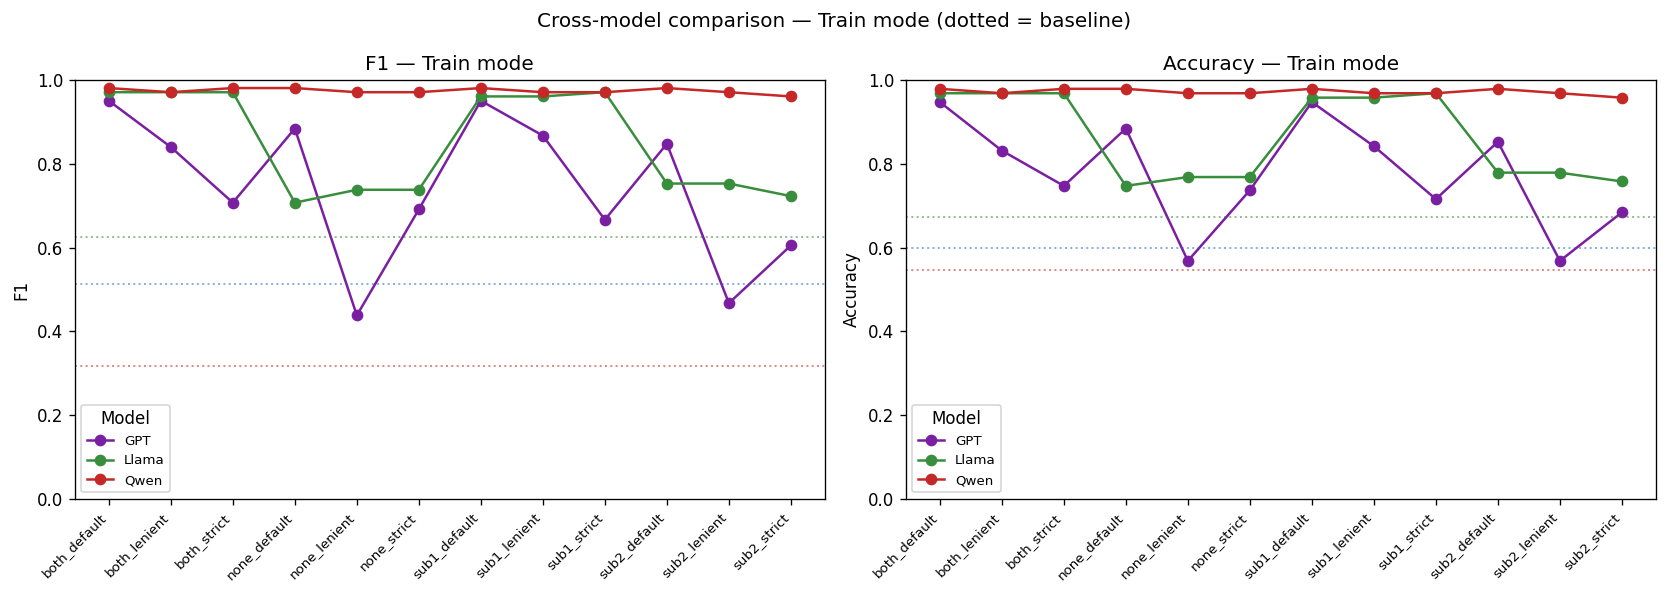

In [42]:
available_models = metrics['model'].unique().tolist()
non_bl = metrics[metrics['run_mode'] != 'baseline'].copy()
bl_rows = metrics[metrics['run_mode'] == 'baseline'].copy()

# ── 4a. Tool vs Train paired comparison — one subplot per model ──────────────
for col, metric_title in [('f1', 'F1 Score (Yes class)'), ('accuracy', 'Accuracy')]:
    fig, axes = plt.subplots(1, len(available_models),
                             figsize=(9 * len(available_models), 7), sharey=True)
    if len(available_models) == 1:
        axes = [axes]
    for ax, model in zip(axes, available_models):
        tool_m  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
        train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
        paired_keys = sorted(set(tool_m.index) & set(train_m.index))
        if not paired_keys:
            ax.set_title(f'{model} — no paired data yet')
            continue
        x = np.arange(len(paired_keys)); w = 0.35
        tool_vals  = [tool_m.loc[k, col]  for k in paired_keys]
        train_vals = [train_m.loc[k, col] for k in paired_keys]
        tc = COMBO_COLORS.get((model, 'tool'),  '#FF9800')
        rc = COMBO_COLORS.get((model, 'train'), '#9C27B0')
        ax.bar(x - w/2, tool_vals,  w, label='Tool',  color=tc, edgecolor='white')
        ax.bar(x + w/2, train_vals, w, label='Train', color=rc, edgecolor='white')
        # baseline ref line
        bl = bl_rows[bl_rows['model'] == model]
        if len(bl):
            ax.axhline(bl.iloc[0][col], color=MODE_COLORS['baseline'],
                       ls='--', lw=1.5, label='Baseline')
        ax.set_xticks(x)
        ax.set_xticklabels(paired_keys, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1); ax.set_title(f'{model}'); ax.legend(fontsize=9)
        for i, k in enumerate(paired_keys):
            delta = train_vals[i] - tool_vals[i]
            color = '#4CAF50' if delta > 0 else '#F44336'
            ax.text(i, max(tool_vals[i], train_vals[i]) + 0.02,
                    f'{delta:+.2f}', ha='center', fontsize=7, color=color)
    plt.suptitle(f'Tool vs Train — {metric_title} (95 TRAIN cases)', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

# ── 4b. Cross-model line charts — separate plots for Tool and Train ───────────
for src_label, src_name in [('tool', 'Tool'), ('train', 'Train')]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in [(axes[0], 'f1', 'F1'), (axes[1], 'accuracy', 'Accuracy')]:
        keys = None
        for model in available_models:
            src_m = non_bl[(non_bl['model']==model) & (non_bl['src']==src_label)].set_index('config_key')
            if src_m.empty:
                continue
            keys = list(src_m[col].sort_index().index)
            vals = src_m[col].sort_index().values
            ax.plot(range(len(keys)), vals, marker='o', label=model,
                    color=COMBO_COLORS.get((model, src_label), MODEL_COLORS.get(model, '#333')))
            # baseline ref line
            bl = bl_rows[bl_rows['model'] == model]
            if len(bl):
                ax.axhline(bl.iloc[0][col], color=MODEL_COLORS.get(model, '#aaa'),
                           ls=':', lw=1.2, alpha=0.5)
        if keys:
            ax.set_xticks(range(len(keys)))
            ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1); ax.set_ylabel(title)
        ax.set_title(f'{title} — {src_name} mode')
        ax.legend(fontsize=8, title='Model')
    plt.suptitle(f'Cross-model comparison — {src_name} mode (dotted = baseline)', fontsize=12)
    plt.tight_layout(); plt.show()


## 5. Train–Tool Delta Table (per model)

How much does having the ground-truth reasoning in the prompt improve each configuration?

In [29]:
delta_by_model = {}   # model → list of delta dicts

for model in available_models:
    tool_m  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
    train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
    paired_keys = sorted(set(tool_m.index) & set(train_m.index))
    delta_rows = []
    for k in paired_keys:
        t = tool_m.loc[k]; r = train_m.loc[k]
        delta_rows.append({
            'model': model, 'config': k,
            'adm_config': t['adm_config'], 'questions': t['questions'],
            'tool_f1': t['f1'], 'train_f1': r['f1'], 'Δf1': r['f1'] - t['f1'],
            'tool_acc': t['accuracy'], 'train_acc': r['accuracy'], 'Δacc': r['accuracy'] - t['accuracy'],
            'tool_prec': t['precision'], 'train_prec': r['precision'], 'Δprec': r['precision'] - t['precision'],
            'tool_rec': t['recall'], 'train_rec': r['recall'], 'Δrec': r['recall'] - t['recall'],
        })
    delta_by_model[model] = delta_rows
    if delta_rows:
        print(f'\n── {model} ──────────────────────────────────────────')
        df = pd.DataFrame(delta_rows).sort_values('Δf1', ascending=False)
        display(df.style.format({
            'tool_f1':'{:.2f}','train_f1':'{:.2f}','Δf1':'{:+.2f}',
            'tool_acc':'{:.1%}','train_acc':'{:.1%}','Δacc':'{:+.1%}',
            'tool_prec':'{:.2f}','train_prec':'{:.2f}','Δprec':'{:+.2f}',
            'tool_rec':'{:.2f}','train_rec':'{:.2f}','Δrec':'{:+.2f}',
        }).background_gradient(subset=['Δf1','Δacc'], cmap='RdYlGn', vmin=-0.3, vmax=0.3))
    else:
        print(f'{model}: paired data not yet available (train results pending?)')


── GPT ──────────────────────────────────────────


,model,config,adm_config,questions,tool_f1,train_f1,Δf1,tool_acc,train_acc,Δacc,tool_prec,train_prec,Δprec,tool_rec,train_rec,Δrec
5,GPT,none_strict,none,strict,0.16,0.69,+0.53,45.3%,73.7%,+28.4%,0.56,1.00,+0.44,0.09,0.53,+0.43
1,GPT,both_lenient,both,lenient,0.38,0.84,+0.46,51.6%,83.2%,+31.6%,0.67,0.89,+0.23,0.26,0.79,+0.53
8,GPT,sub1_strict,sub1,strict,0.29,0.67,+0.37,49.5%,71.6%,+22.1%,0.67,0.96,+0.30,0.19,0.51,+0.32
0,GPT,both_default,both,default,0.64,0.95,+0.31,57.9%,94.7%,+36.8%,0.61,1.00,+0.39,0.66,0.91,+0.25
3,GPT,none_default,none,default,0.59,0.88,+0.30,60.0%,88.4%,+28.4%,0.69,1.00,+0.31,0.51,0.79,+0.28
11,GPT,sub2_strict,sub2,strict,0.31,0.61,+0.29,49.5%,68.4%,+18.9%,0.65,1.00,+0.35,0.21,0.43,+0.23
9,GPT,sub2_default,sub2,default,0.57,0.85,+0.27,57.9%,85.3%,+27.4%,0.66,1.00,+0.34,0.51,0.74,+0.23
6,GPT,sub1_default,sub1,default,0.69,0.95,+0.26,65.3%,94.7%,+29.5%,0.69,1.00,+0.31,0.68,0.91,+0.23
2,GPT,both_strict,both,strict,0.46,0.71,+0.24,53.7%,74.7%,+21.1%,0.66,1.00,+0.34,0.36,0.55,+0.19
10,GPT,sub2_lenient,sub2,lenient,0.31,0.47,+0.16,53.7%,56.8%,+3.2%,0.91,0.75,-0.16,0.19,0.34,+0.15



── Llama ──────────────────────────────────────────


,model,config,adm_config,questions,tool_f1,train_f1,Δf1,tool_acc,train_acc,Δacc,tool_prec,train_prec,Δprec,tool_rec,train_rec,Δrec
1,Llama,both_lenient,both,lenient,0.07,0.97,+0.90,46.3%,96.8%,+50.5%,1.00,1.00,+0.00,0.04,0.94,+0.91
2,Llama,both_strict,both,strict,0.07,0.97,+0.90,46.3%,96.8%,+50.5%,1.00,1.00,+0.00,0.04,0.94,+0.91
8,Llama,sub1_strict,sub1,strict,0.07,0.97,+0.90,46.3%,96.8%,+50.5%,1.00,1.00,+0.00,0.04,0.94,+0.91
10,Llama,sub2_lenient,sub2,lenient,0.00,0.75,+0.75,44.2%,77.9%,+33.7%,0.00,1.00,+1.00,0.00,0.60,+0.60
4,Llama,none_lenient,none,lenient,0.00,0.74,+0.74,42.1%,76.8%,+34.7%,0.00,1.00,+1.00,0.00,0.58,+0.58
11,Llama,sub2_strict,sub2,strict,0.04,0.72,+0.69,45.3%,75.8%,+30.5%,1.00,1.00,+0.00,0.02,0.57,+0.55
5,Llama,none_strict,none,strict,0.07,0.74,+0.67,46.3%,76.8%,+30.5%,1.00,1.00,+0.00,0.04,0.58,+0.55
7,Llama,sub1_lenient,sub1,lenient,0.46,0.96,+0.50,52.6%,95.8%,+43.2%,0.63,1.00,+0.37,0.36,0.92,+0.57
6,Llama,sub1_default,sub1,default,0.72,0.96,+0.24,62.1%,95.8%,+33.7%,0.61,1.00,+0.39,0.89,0.92,+0.04
0,Llama,both_default,both,default,0.74,0.97,+0.23,63.2%,96.8%,+33.7%,0.61,1.00,+0.39,0.96,0.94,-0.02



── Qwen ──────────────────────────────────────────


,model,config,adm_config,questions,tool_f1,train_f1,Δf1,tool_acc,train_acc,Δacc,tool_prec,train_prec,Δprec,tool_rec,train_rec,Δrec
8,Qwen,sub1_strict,sub1,strict,0.70,0.97,+0.27,69.5%,96.8%,+27.4%,0.77,1.00,+0.23,0.64,0.94,+0.30
2,Qwen,both_strict,both,strict,0.72,0.98,+0.26,68.4%,97.9%,+29.5%,0.71,1.00,+0.29,0.74,0.96,+0.23
10,Qwen,sub2_lenient,sub2,lenient,0.74,0.97,+0.23,68.4%,96.8%,+28.4%,0.69,1.00,+0.31,0.79,0.94,+0.15
6,Qwen,sub1_default,sub1,default,0.75,0.98,+0.23,68.4%,97.9%,+29.5%,0.67,1.00,+0.33,0.87,0.96,+0.09
9,Qwen,sub2_default,sub2,default,0.76,0.98,+0.22,73.7%,97.9%,+24.2%,0.78,1.00,+0.22,0.74,0.96,+0.23
11,Qwen,sub2_strict,sub2,strict,0.75,0.96,+0.22,70.5%,95.8%,+25.3%,0.72,1.00,+0.28,0.77,0.92,+0.15
3,Qwen,none_default,none,default,0.77,0.98,+0.21,73.7%,97.9%,+24.2%,0.76,1.00,+0.24,0.77,0.96,+0.19
5,Qwen,none_strict,none,strict,0.76,0.97,+0.21,75.8%,96.8%,+21.1%,0.86,1.00,+0.14,0.68,0.94,+0.26
4,Qwen,none_lenient,none,lenient,0.77,0.97,+0.21,71.6%,96.8%,+25.3%,0.71,1.00,+0.29,0.83,0.94,+0.11
7,Qwen,sub1_lenient,sub1,lenient,0.79,0.97,+0.18,72.6%,96.8%,+24.2%,0.69,1.00,+0.31,0.92,0.94,+0.02


## 6. Average Improvement by ADM Config & Question Type

Which ADM configurations and question framings benefit most from oracle guidance?

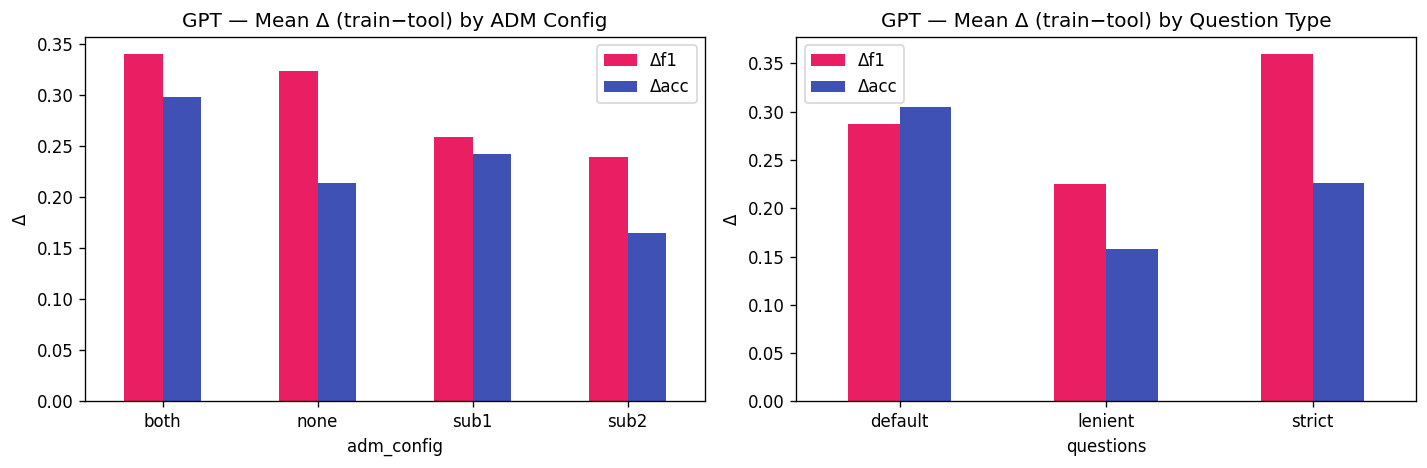

GPT — By ADM config:


,Δf1,Δacc
adm_config,,
both,0.340,0.298
none,0.324,0.214
sub1,0.259,0.242
sub2,0.240,0.165


GPT — By Question type:


,Δf1,Δacc
questions,,
default,0.287,0.305
lenient,0.225,0.158
strict,0.359,0.226


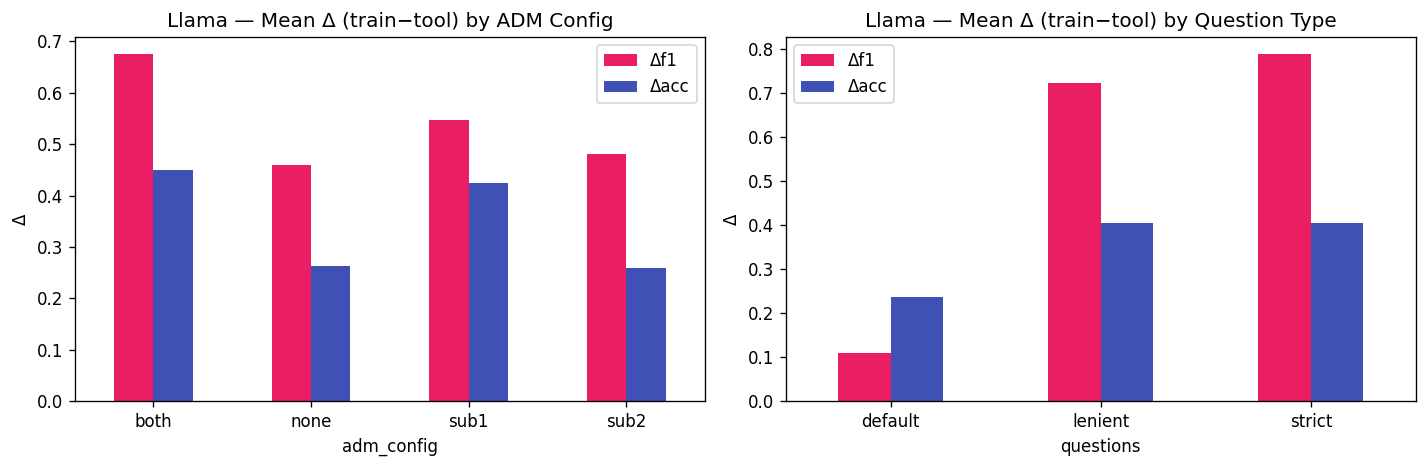

Llama — By ADM config:


,Δf1,Δacc
adm_config,,
both,0.674,0.449
none,0.459,0.263
sub1,0.546,0.425
sub2,0.481,0.260


Llama — By Question type:


,Δf1,Δacc
questions,,
default,0.110,0.237
lenient,0.723,0.405
strict,0.787,0.405


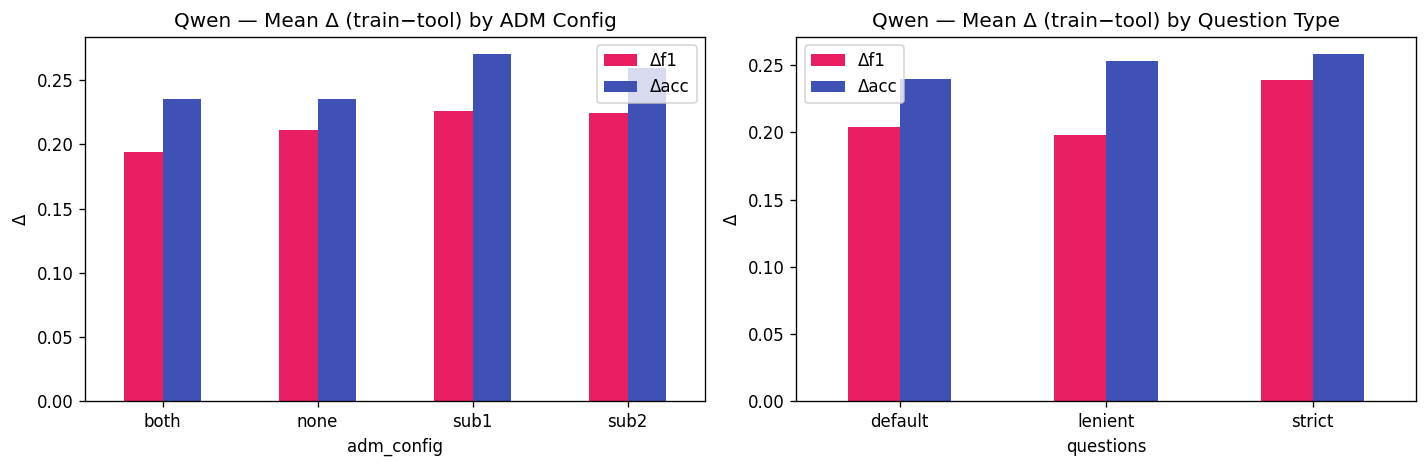

Qwen — By ADM config:


,Δf1,Δacc
adm_config,,
both,0.194,0.235
none,0.211,0.235
sub1,0.226,0.270
sub2,0.224,0.260


Qwen — By Question type:


,Δf1,Δacc
questions,,
default,0.204,0.239
lenient,0.198,0.253
strict,0.239,0.258


In [30]:
for model in available_models:
    delta_rows = delta_by_model.get(model, [])
    if not delta_rows:
        print(f'{model}: no paired data yet'); continue
    ddf = pd.DataFrame(delta_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grp_adm = ddf.groupby('adm_config')[['Δf1','Δacc']].mean()
    grp_adm.plot(kind='bar', ax=axes[0], color=['#E91E63','#3F51B5'])
    axes[0].set_title(f'{model} — Mean Δ (train−tool) by ADM Config')
    axes[0].set_ylabel('Δ'); axes[0].tick_params(axis='x', rotation=0)
    axes[0].axhline(0, color='black', lw=0.5)
    grp_q = ddf.groupby('questions')[['Δf1','Δacc']].mean()
    grp_q.plot(kind='bar', ax=axes[1], color=['#E91E63','#3F51B5'])
    axes[1].set_title(f'{model} — Mean Δ (train−tool) by Question Type')
    axes[1].set_ylabel('Δ'); axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(0, color='black', lw=0.5)
    plt.tight_layout(); plt.show()
    print(f'{model} — By ADM config:'); display(grp_adm.round(3))
    print(f'{model} — By Question type:'); display(grp_q.round(3))

## 7. Confusion Matrices — Best ADM Config (Tool vs Train, per model)

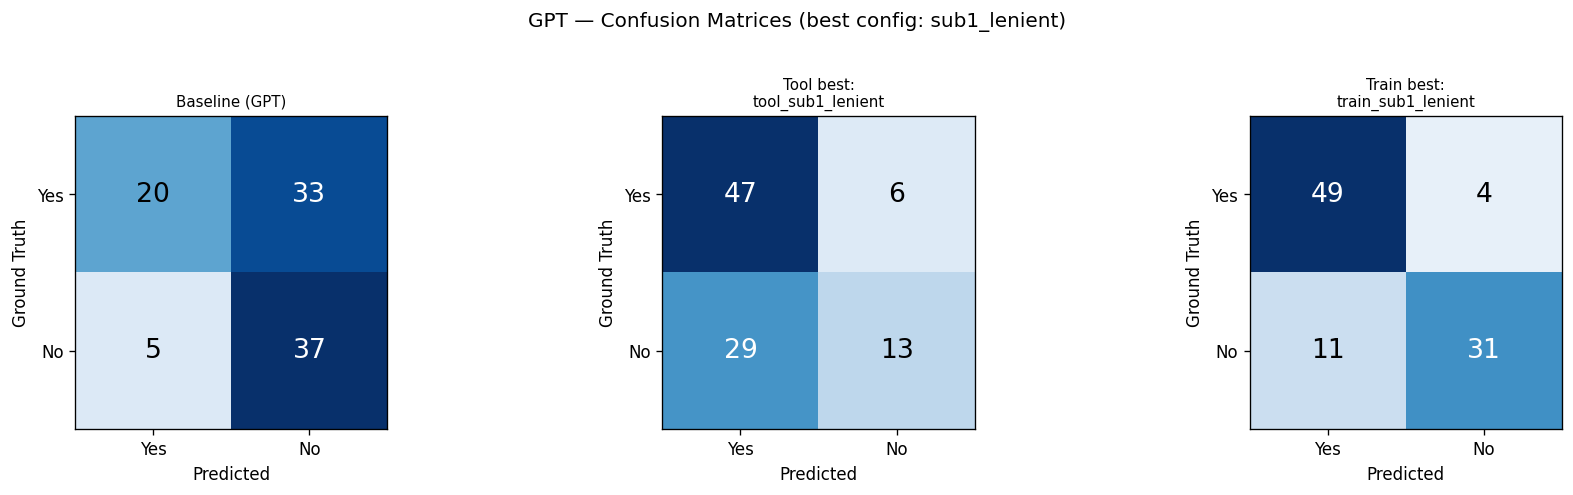

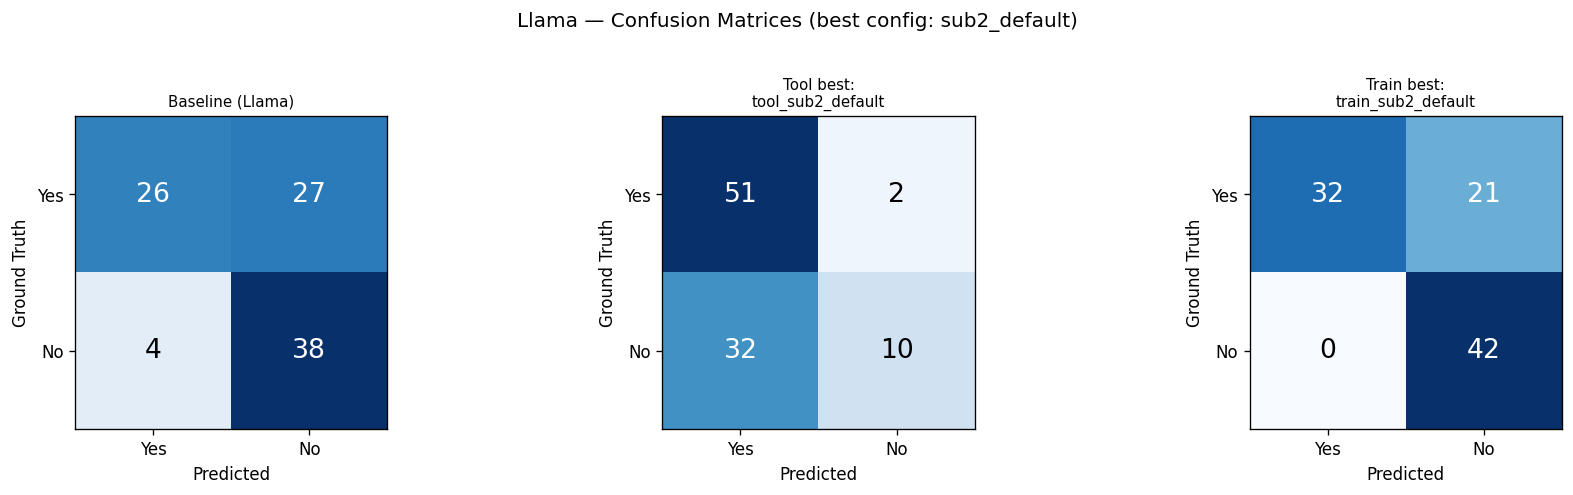

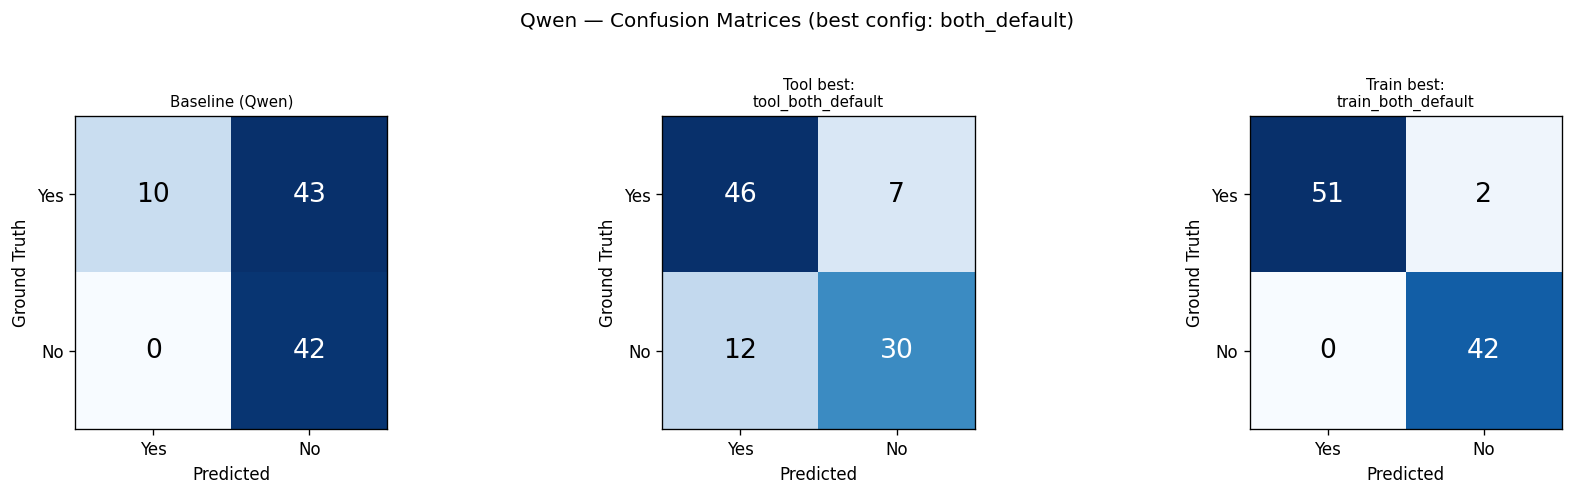

In [31]:
def plot_cm(preds, gt, title, ax):
    cm = Counter()
    for cid, p in preds.items():
        t = gt.get(cid)
        if t and t != 'MISSING' and p in ('Yes','No'):
            cm[(t, p)] += 1
    labels = ['Yes','No']
    mat = [[cm.get((t,p),0) for p in labels] for t in labels]
    ax.imshow(mat, cmap='Blues', vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(mat[i][j]), ha='center', va='center',
                    fontsize=16, color='white' if mat[i][j] > 20 else 'black')

for model in available_models:
    model_preds = {k: v for (m, k), v in all_preds.items() if m == model}
    tool_p  = model_preds.get('tool',  {})
    train_p = model_preds.get('train', {})
    if not tool_p:
        print(f'{model}: no tool predictions yet'); continue

    nb_tool  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')]
    best_tool_row = nb_tool.sort_values('f1', ascending=False).iloc[0] if len(nb_tool) else None
    best_key = best_tool_row['config_key'] if best_tool_row is not None else None
    best_tool_name = best_tool_row['experiment'] if best_tool_row is not None else None

    # Find matching train experiment
    best_train_name = None
    if train_p and best_key:
        candidates = [n for n in train_p if
                      n.replace('train_','') == best_key or n == 'train_' + best_key]
        best_train_name = candidates[0] if candidates else None

    bl_name = next((n for n in tool_p if 'baseline' in n), None)
    panels = [(f'Baseline ({model})', tool_p.get(bl_name, {}))]
    if best_tool_name:
        panels.append((f'Tool best:\n{best_tool_name}', tool_p.get(best_tool_name, {})))
    if best_train_name:
        panels.append((f'Train best:\n{best_train_name}', train_p.get(best_train_name, {})))

    fig, axes = plt.subplots(1, len(panels), figsize=(5*len(panels), 4))
    if len(panels) == 1: axes = [axes]
    for ax, (title, preds) in zip(axes, panels):
        plot_cm(preds, gt_train, title, ax)
    plt.suptitle(f'{model} — Confusion Matrices (best config: {best_key})', y=1.02)
    plt.tight_layout(); plt.show()

## 8. Per-Case Diagnosis — Where Tool Fails but Train Succeeds

These are cases where the LLM gets the answer **right** with oracle guidance but **wrong** without it. This is the "ADM gap" — the ADM's question-answering isn't guiding the LLM to the correct factors.

In [32]:
gap_cases_by_model = {}   # model → {config_key: list of (cid, tool_pred, train_pred, truth)}

for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p or not train_p:
        print(f'{model}: tool/train not both available — skipping gap analysis')
        gap_cases_by_model[model] = {}
        continue

    tool_m_idx  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
    paired_keys = sorted(set(tool_m_idx.index) &
                         set(non_bl[(non_bl['model']==model) & (non_bl['src']=='train')]['config_key']))
    gap_cases = {}
    for k in paired_keys:
        tool_exp  = [n for n in tool_p  if n.replace('tool_','')  == k or n == 'tool_'+k]
        train_exp = [n for n in train_p if n.replace('train_','') == k or n == 'train_'+k]
        if not tool_exp or not train_exp: continue
        tp = tool_p[tool_exp[0]]; rp = train_p[train_exp[0]]
        gaps = []
        for cid in train_cases:
            truth = gt_train.get(cid)
            if truth and truth != 'MISSING':
                if tp.get(cid) != truth and rp.get(cid) == truth:
                    gaps.append((cid, tp.get(cid), rp.get(cid), truth))
        gap_cases[k] = gaps
    gap_cases_by_model[model] = gap_cases

    gap_counter = Counter()
    for k, gaps in gap_cases.items():
        for cid, _, _, _ in gaps: gap_counter[cid] += 1

    print(f'\n── {model} ── Cases where TRAIN correct but TOOL wrong ──')
    for k in paired_keys:
        g = gap_cases.get(k, [])
        print(f'  {k:30s}: {len(g)} gap cases')
    print(f'\nTop 10 most frequent gap cases ({model}):')
    for cid, count in gap_counter.most_common(10):
        print(f'  {cid}: gap in {count}/{len(paired_keys)} configs (truth={gt_train[cid]})')


── GPT ── Cases where TRAIN correct but TOOL wrong ──
  both_default                  : 38 gap cases
  both_lenient                  : 37 gap cases
  both_strict                   : 30 gap cases
  none_default                  : 33 gap cases
  none_lenient                  : 17 gap cases
  none_strict                   : 28 gap cases
  sub1_default                  : 30 gap cases
  sub1_lenient                  : 26 gap cases
  sub1_strict                   : 26 gap cases
  sub2_default                  : 30 gap cases
  sub2_lenient                  : 16 gap cases
  sub2_strict                   : 23 gap cases

Top 10 most frequent gap cases (GPT):
  T078811: gap in 8/12 configs (truth=Yes)
  T112211: gap in 8/12 configs (truth=Yes)
  T184111: gap in 8/12 configs (truth=No)
  T190310: gap in 8/12 configs (truth=Yes)
  T007714: gap in 7/12 configs (truth=Yes)
  T052011: gap in 7/12 configs (truth=Yes)
  T071810: gap in 7/12 configs (truth=Yes)
  T077614: gap in 7/12 configs (truth=Yes)

## 9. Gap Analysis — Error Direction

When tool mode fails on cases that train gets right, which direction is the error?
- **FN gap** (tool says No, truth is Yes) = tool is too conservative / misses inventive step
- **FP gap** (tool says Yes, truth is No) = tool is too generous / hallucinating inventive step

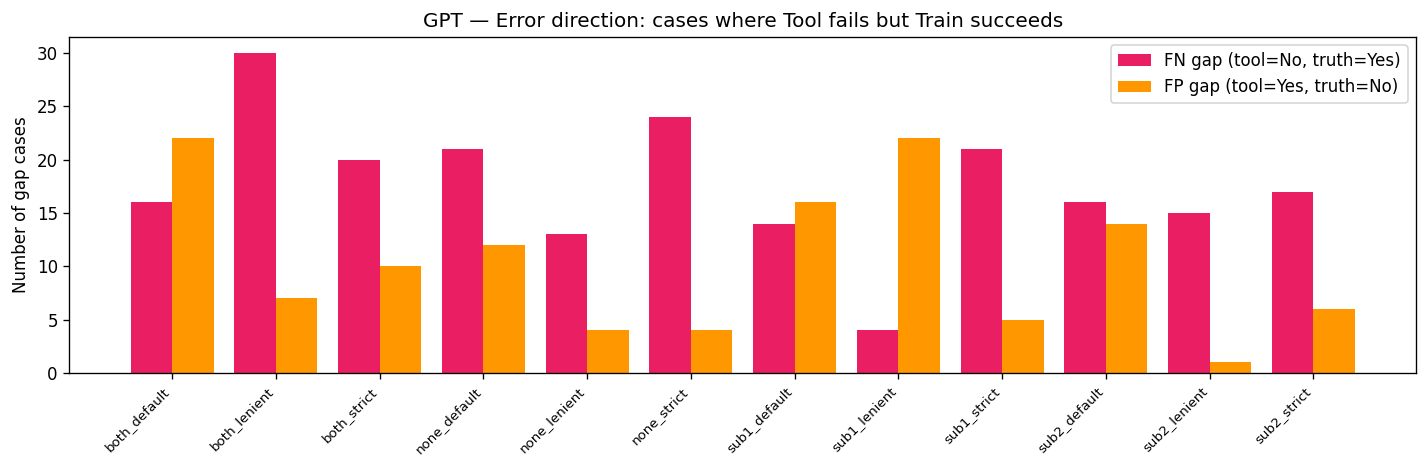

GPT: 211 FN gaps, 123 FP gaps — 63% conservative


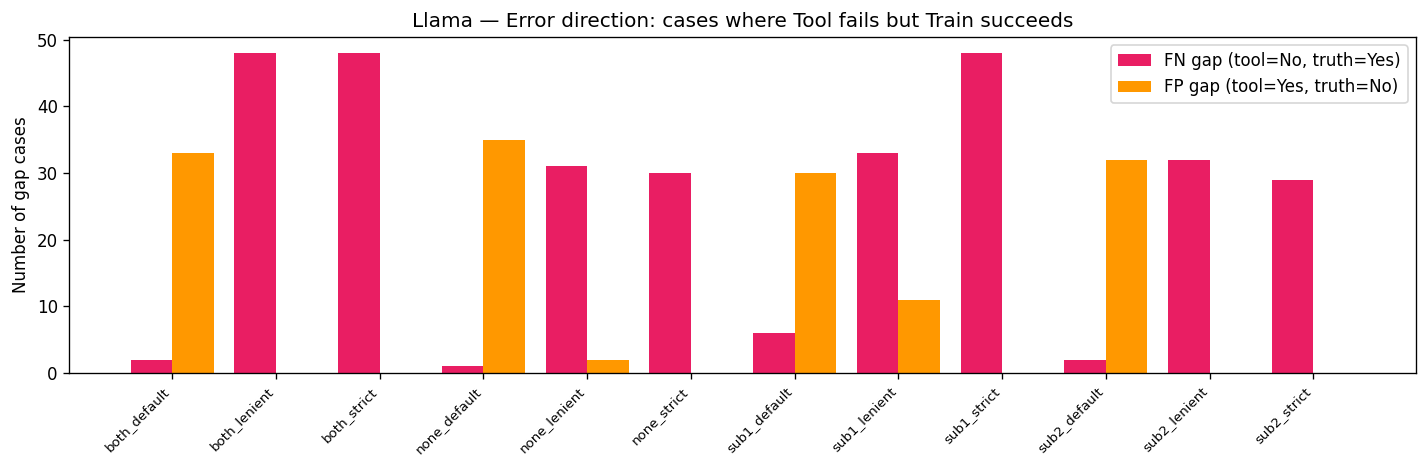

Llama: 310 FN gaps, 143 FP gaps — 68% conservative


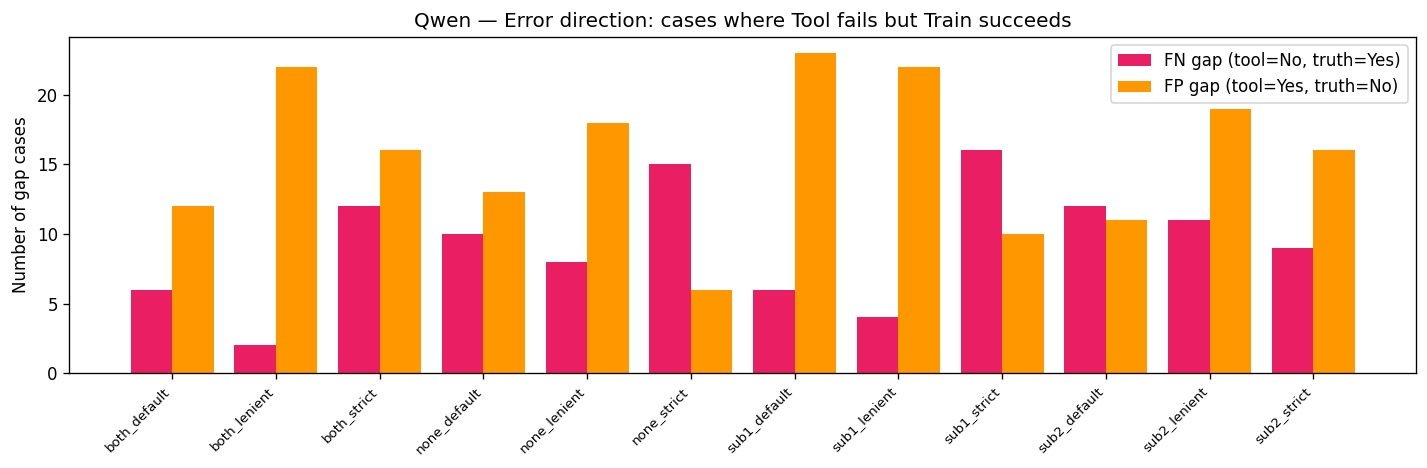

Qwen: 111 FN gaps, 188 FP gaps — 37% conservative


In [33]:
total_fn_by_model = {}
total_fp_by_model = {}

for model in available_models:
    gap_cases = gap_cases_by_model.get(model, {})
    if not gap_cases:
        total_fn_by_model[model] = 0; total_fp_by_model[model] = 0; continue
    paired_keys = sorted(gap_cases.keys())
    err_rows = []
    for k in paired_keys:
        gaps = gap_cases.get(k, [])
        fn_gaps = sum(1 for _, tp, _, tr in gaps if tr == 'Yes' and tp == 'No')
        fp_gaps = sum(1 for _, tp, _, tr in gaps if tr == 'No'  and tp == 'Yes')
        err_rows.append({'config': k, 'FN_gaps': fn_gaps, 'FP_gaps': fp_gaps,
                         'total_gaps': fn_gaps+fp_gaps})
    err_df = pd.DataFrame(err_rows)
    total_fn = err_df['FN_gaps'].sum(); total_fp = err_df['FP_gaps'].sum()
    total_fn_by_model[model] = total_fn; total_fp_by_model[model] = total_fp

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(err_df))
    ax.bar(x - 0.2, err_df['FN_gaps'], 0.4, label='FN gap (tool=No, truth=Yes)', color='#E91E63')
    ax.bar(x + 0.2, err_df['FP_gaps'], 0.4, label='FP gap (tool=Yes, truth=No)', color='#FF9800')
    ax.set_xticks(x); ax.set_xticklabels(err_df['config'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of gap cases')
    ax.set_title(f'{model} — Error direction: cases where Tool fails but Train succeeds')
    ax.legend(); plt.tight_layout(); plt.show()
    if total_fn + total_fp > 0:
        print(f'{model}: {total_fn} FN gaps, {total_fp} FP gaps — '
              f'{total_fn/(total_fn+total_fp):.0%} conservative')

## 10. Prediction Heatmap — Tool vs Train per Model (all experiments × cases)

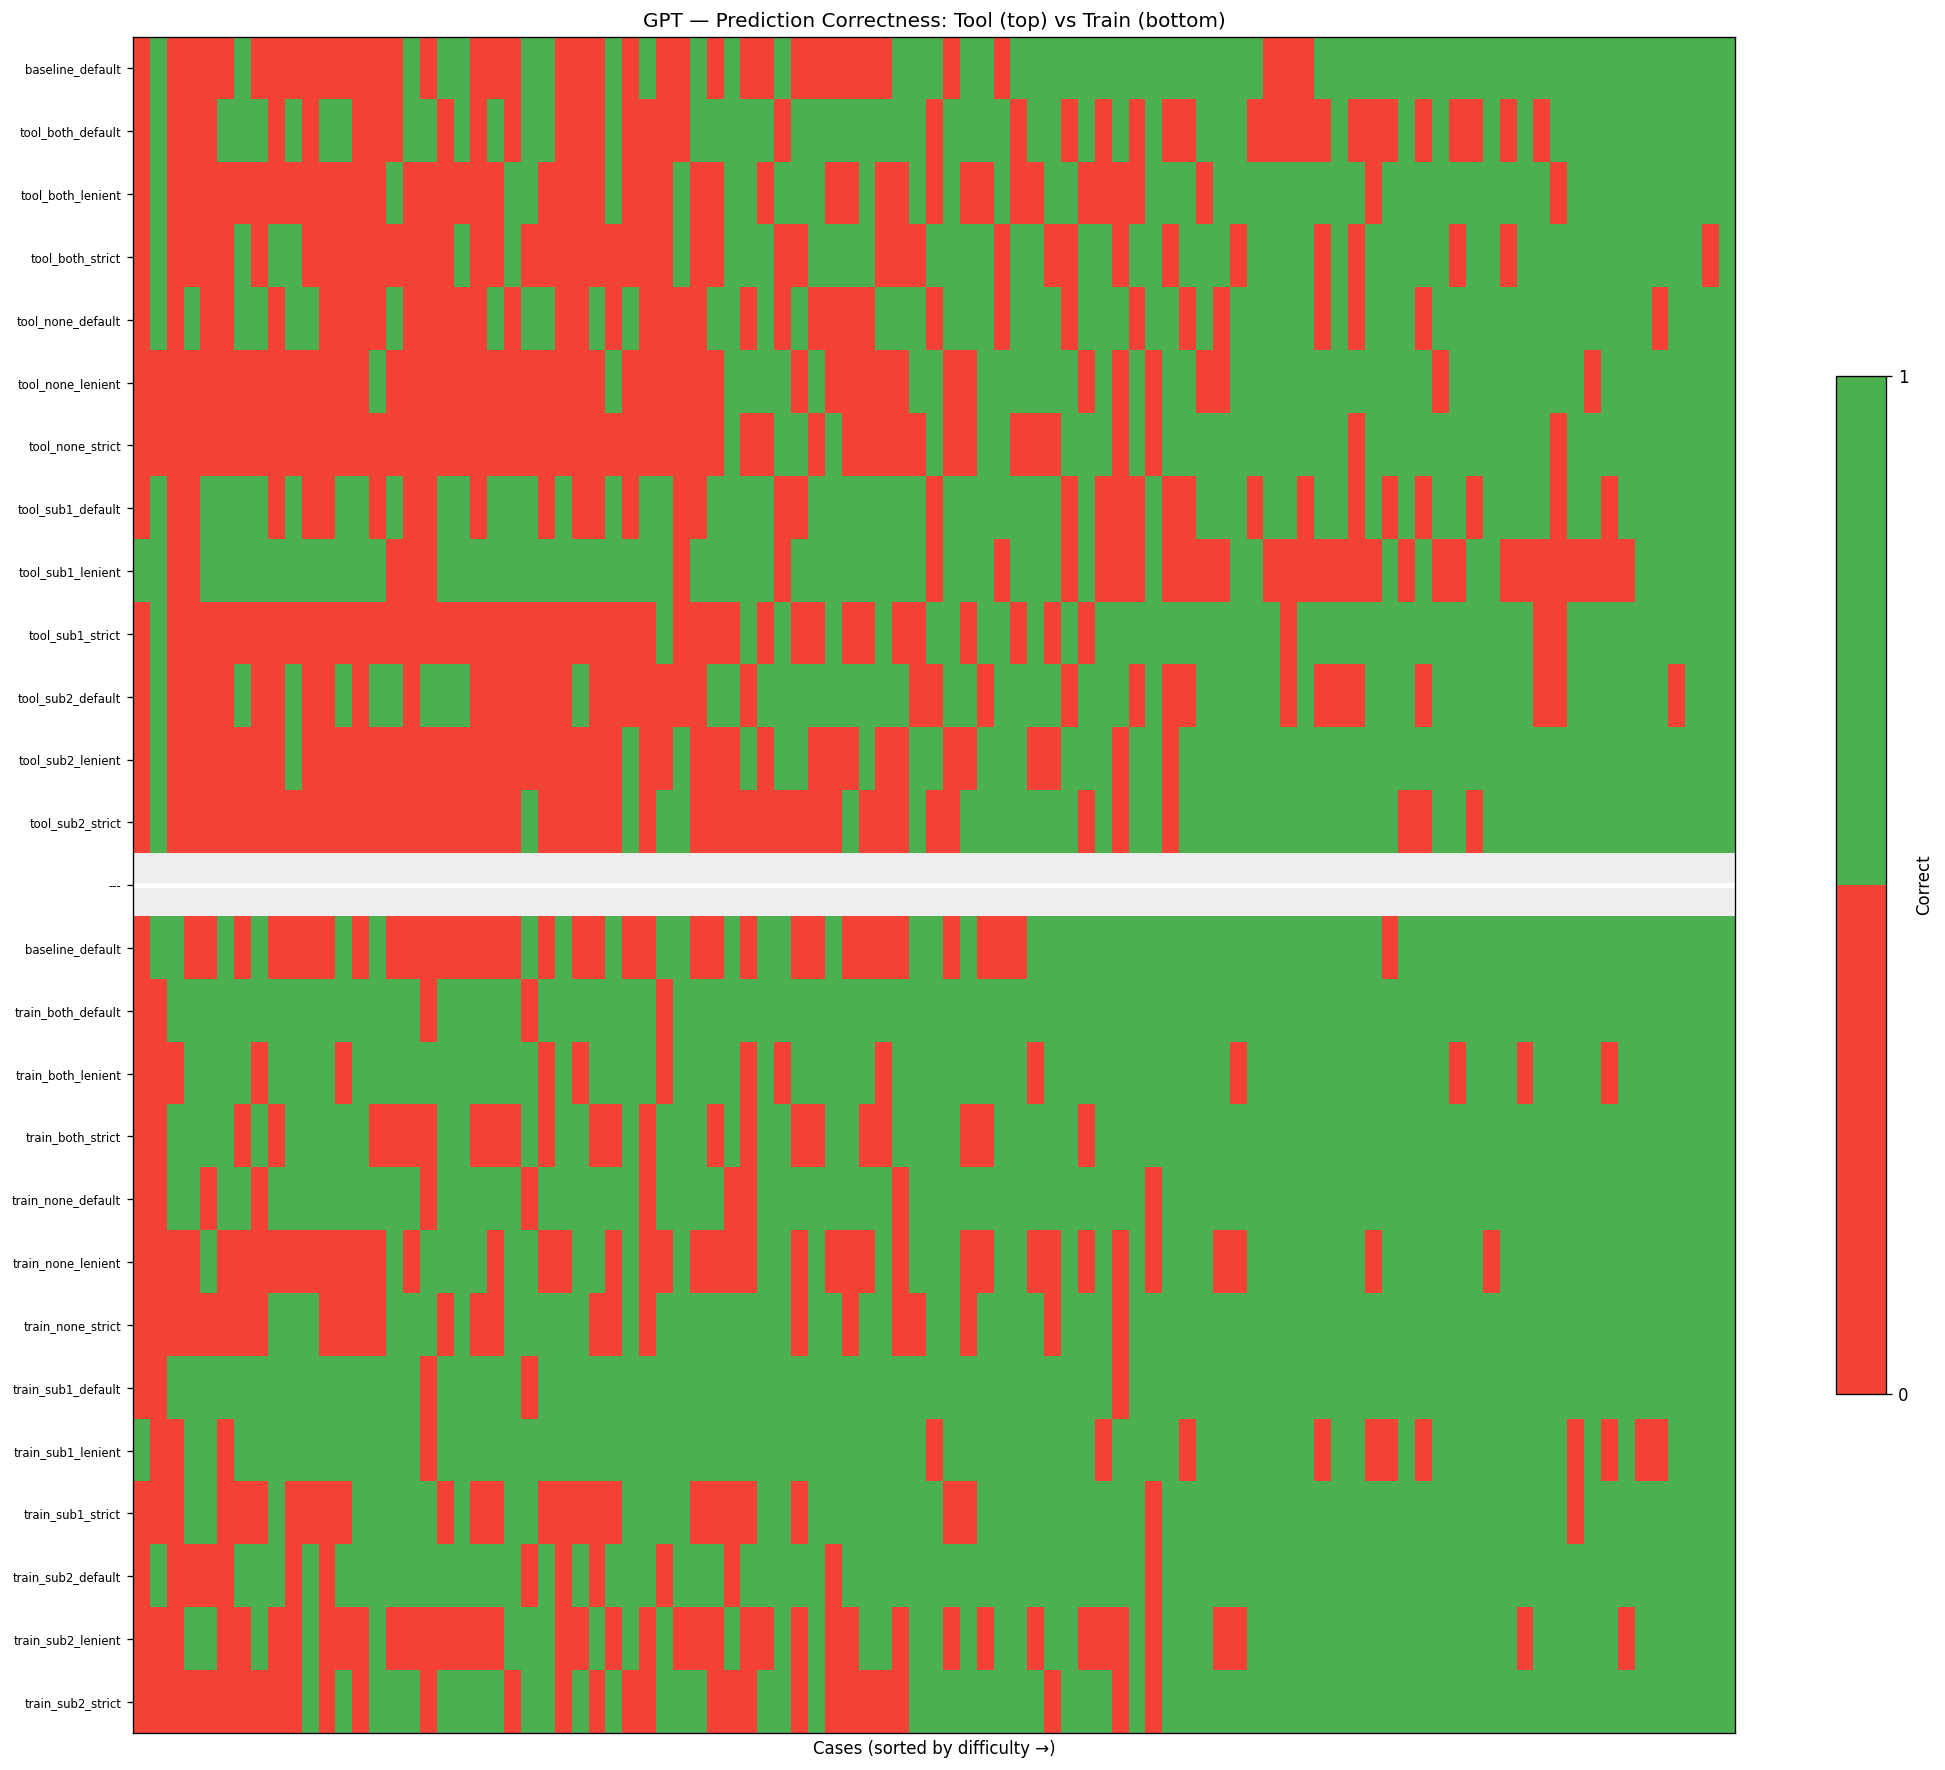

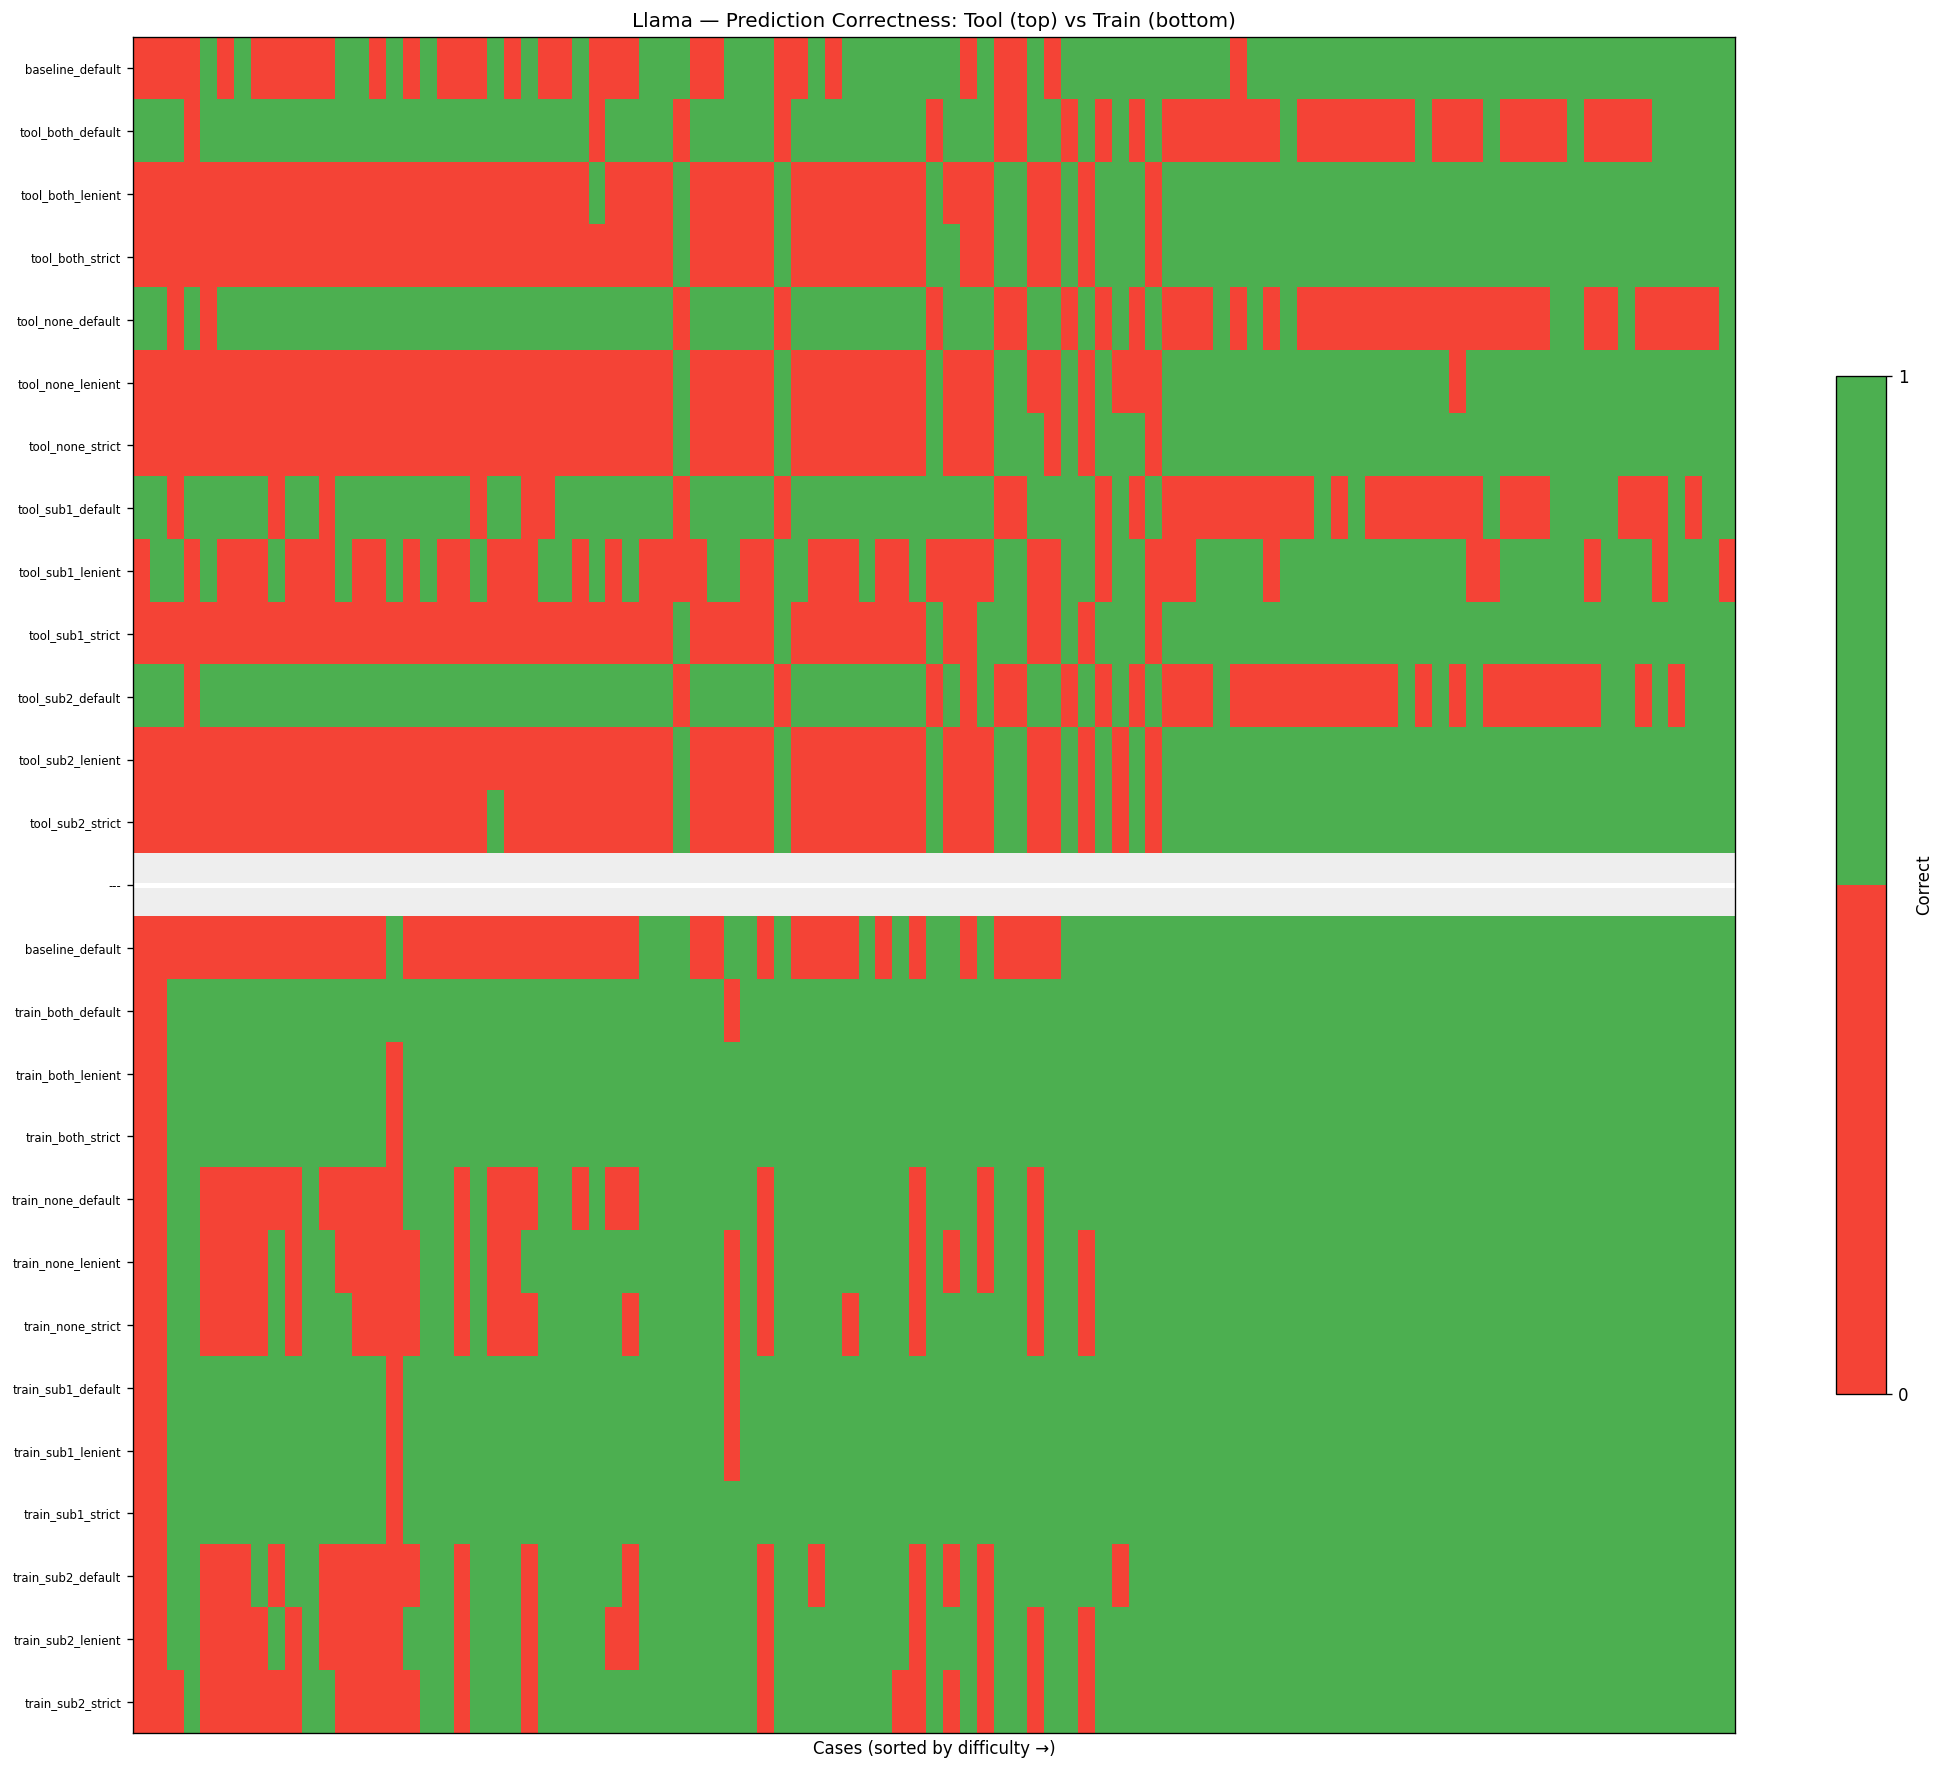

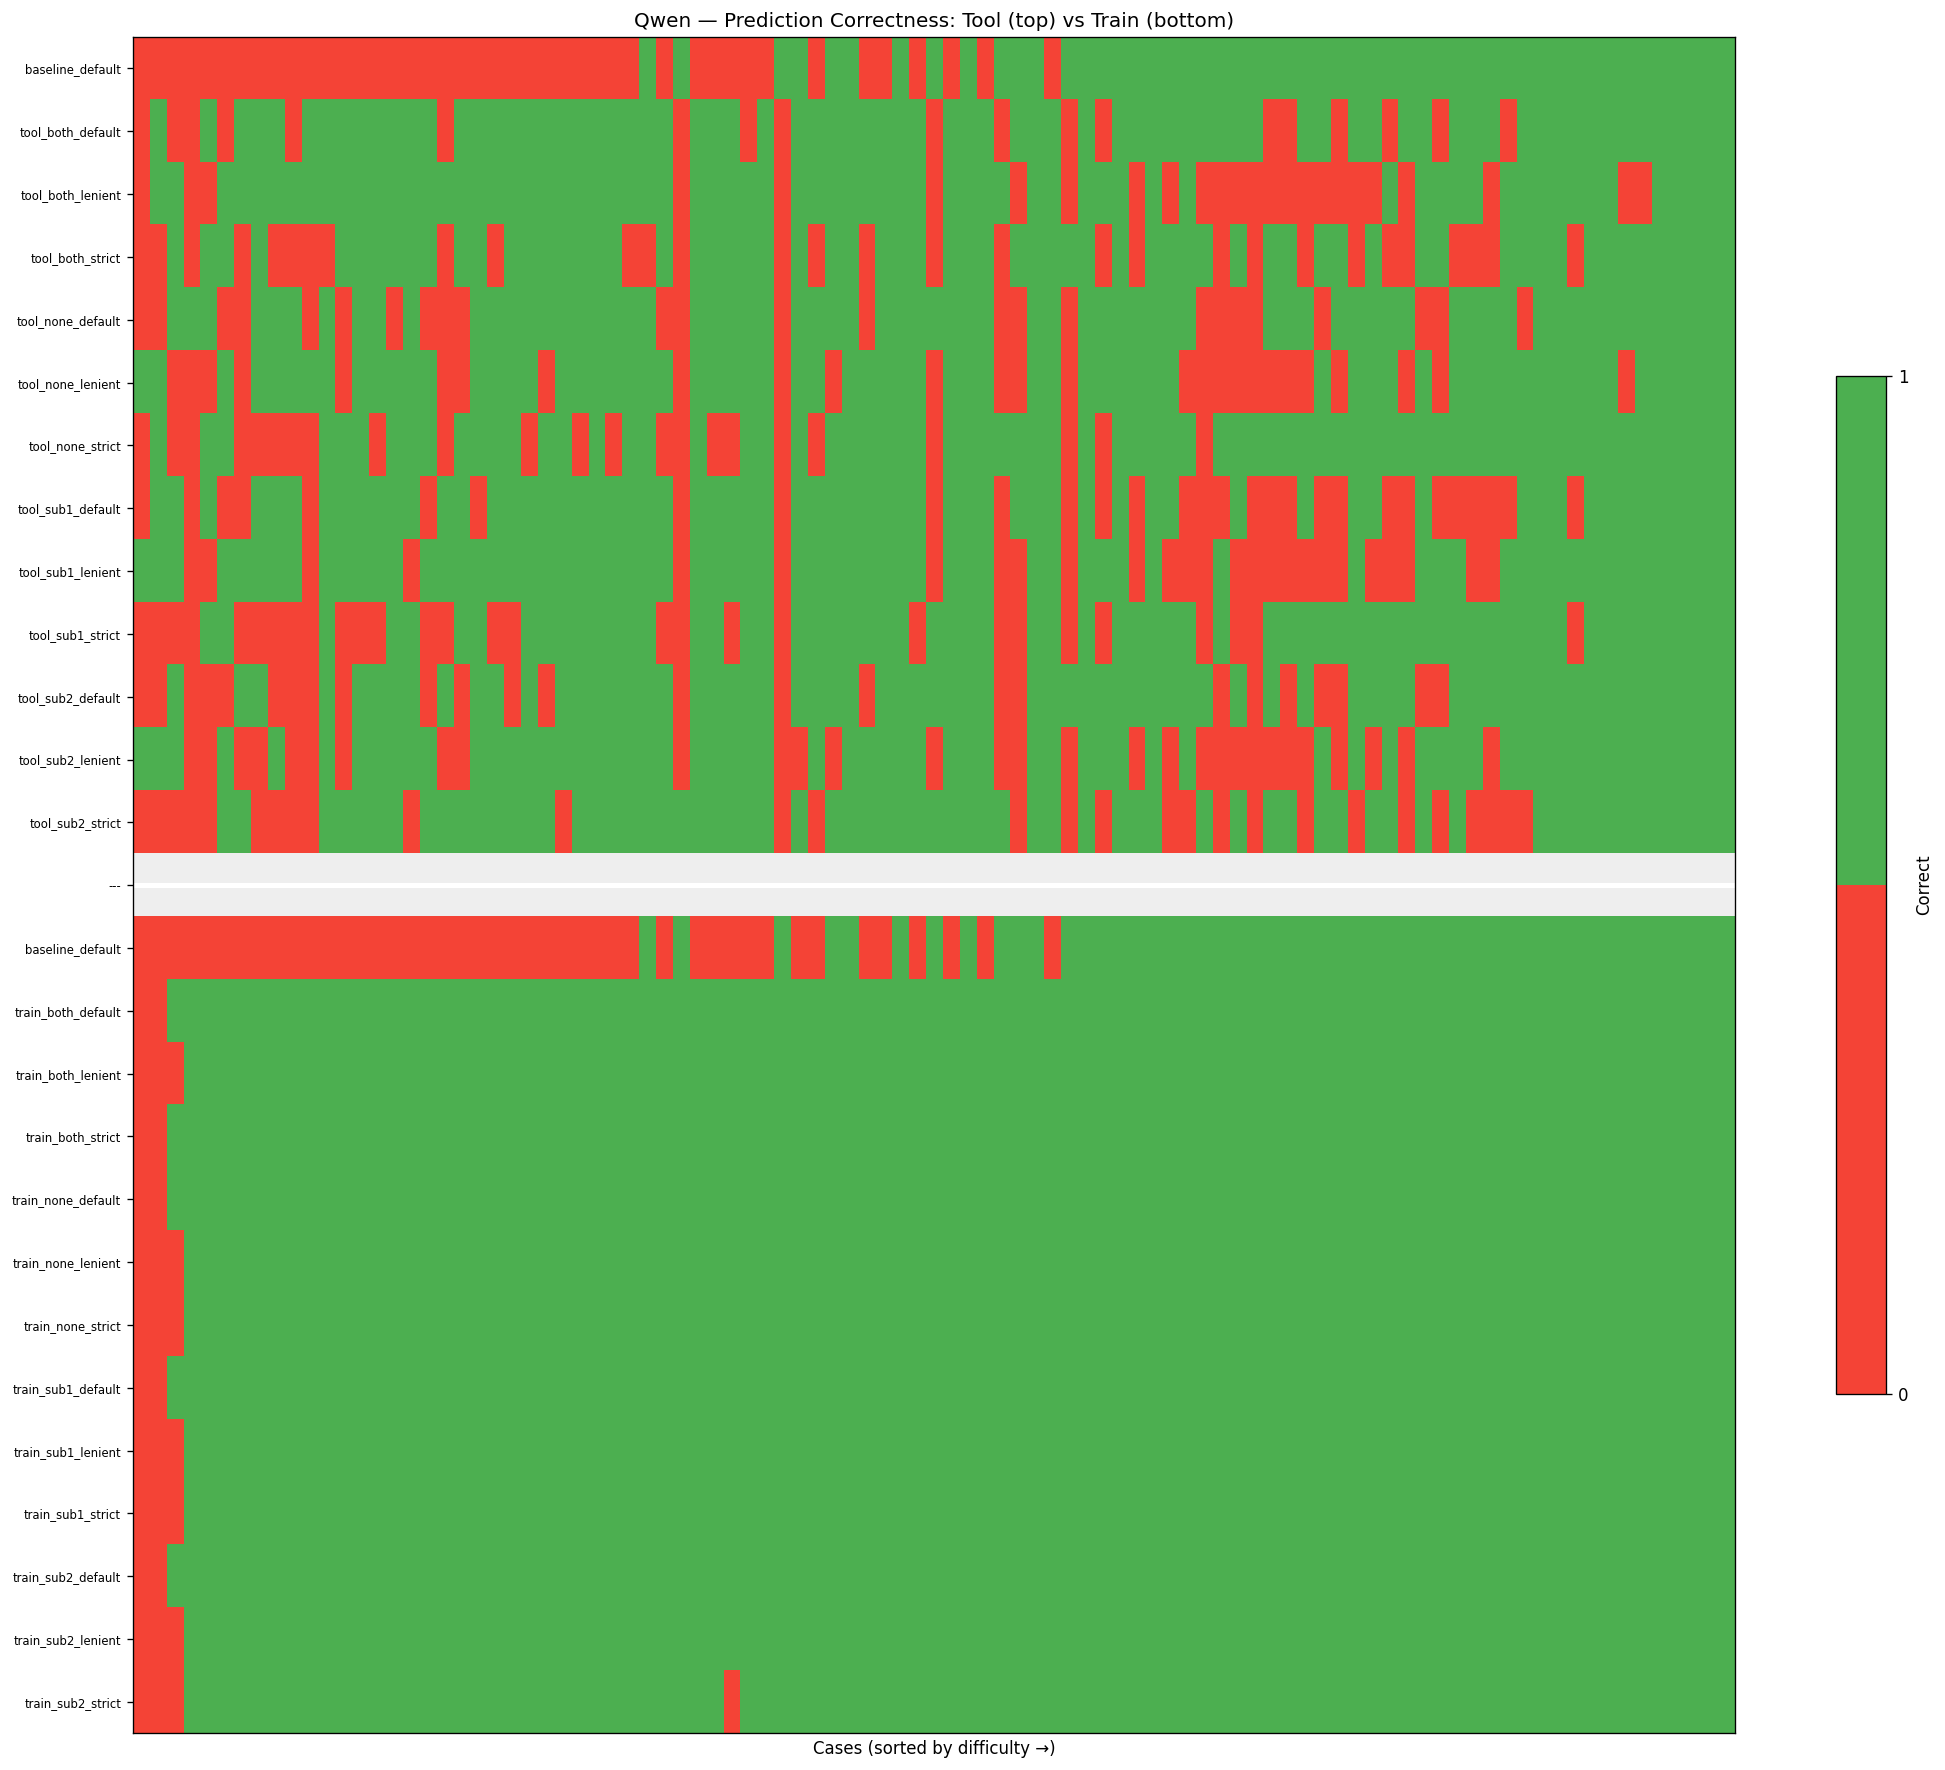

In [34]:
# Sort cases by overall difficulty (fraction correct across ALL experiments)
all_combined_flat = {f'{m}_{s}_{n}': p
                     for (m, s), exps in all_preds.items()
                     for n, p in exps.items()}
case_correct_all = {c: 0 for c in train_cases}
case_total_all   = {c: 0 for c in train_cases}
for preds in all_combined_flat.values():
    for cid, pred in preds.items():
        if cid in gt_train and gt_train[cid] != 'MISSING' and pred in ('Yes','No'):
            case_total_all[cid] += 1
            if pred == gt_train[cid]: case_correct_all[cid] += 1
case_frac  = {c: case_correct_all[c]/case_total_all[c] if case_total_all[c] else 0
              for c in train_cases}
sorted_cases = sorted(train_cases, key=lambda c: case_frac[c])

cmap = matplotlib.colors.ListedColormap(['#F44336', '#4CAF50'])
cmap.set_bad('#EEEEEE')

for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p:
        print(f'{model}: no tool predictions yet'); continue
    tool_names  = sorted(tool_p.keys())
    train_names = sorted(train_p.keys()) if train_p else []
    all_names   = tool_names + (['---'] if train_names else []) + train_names
    nrows = len(tool_names) + (1 if train_names else 0) + len(train_names)
    matrix = np.full((nrows, len(sorted_cases)), np.nan)
    for i, exp in enumerate(tool_names):
        for j, c in enumerate(sorted_cases):
            p = tool_p[exp].get(c); t = gt_train.get(c)
            if p and t and t != 'MISSING' and p in ('Yes','No'):
                matrix[i, j] = 1.0 if p == t else 0.0
    if train_names:
        for i, exp in enumerate(train_names):
            for j, c in enumerate(sorted_cases):
                p = train_p[exp].get(c); t = gt_train.get(c)
                if p and t and t != 'MISSING' and p in ('Yes','No'):
                    matrix[len(tool_names)+1+i, j] = 1.0 if p == t else 0.0
    fig, ax = plt.subplots(figsize=(18, max(6, nrows * 0.55)))
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    ax.set_yticks(range(len(all_names))); ax.set_yticklabels(all_names, fontsize=7)
    ax.set_xlabel('Cases (sorted by difficulty →)')
    ax.set_title(f'{model} — Prediction Correctness: Tool (top) vs Train (bottom)')
    ax.set_xticks([])
    if train_names:
        ax.axhline(len(tool_names) - 0.5 + 0.5, color='white', lw=3)
    plt.colorbar(im, ax=ax, ticks=[0,1], label='Correct', shrink=0.6)
    plt.tight_layout(); plt.show()

## 11. Timing Comparison

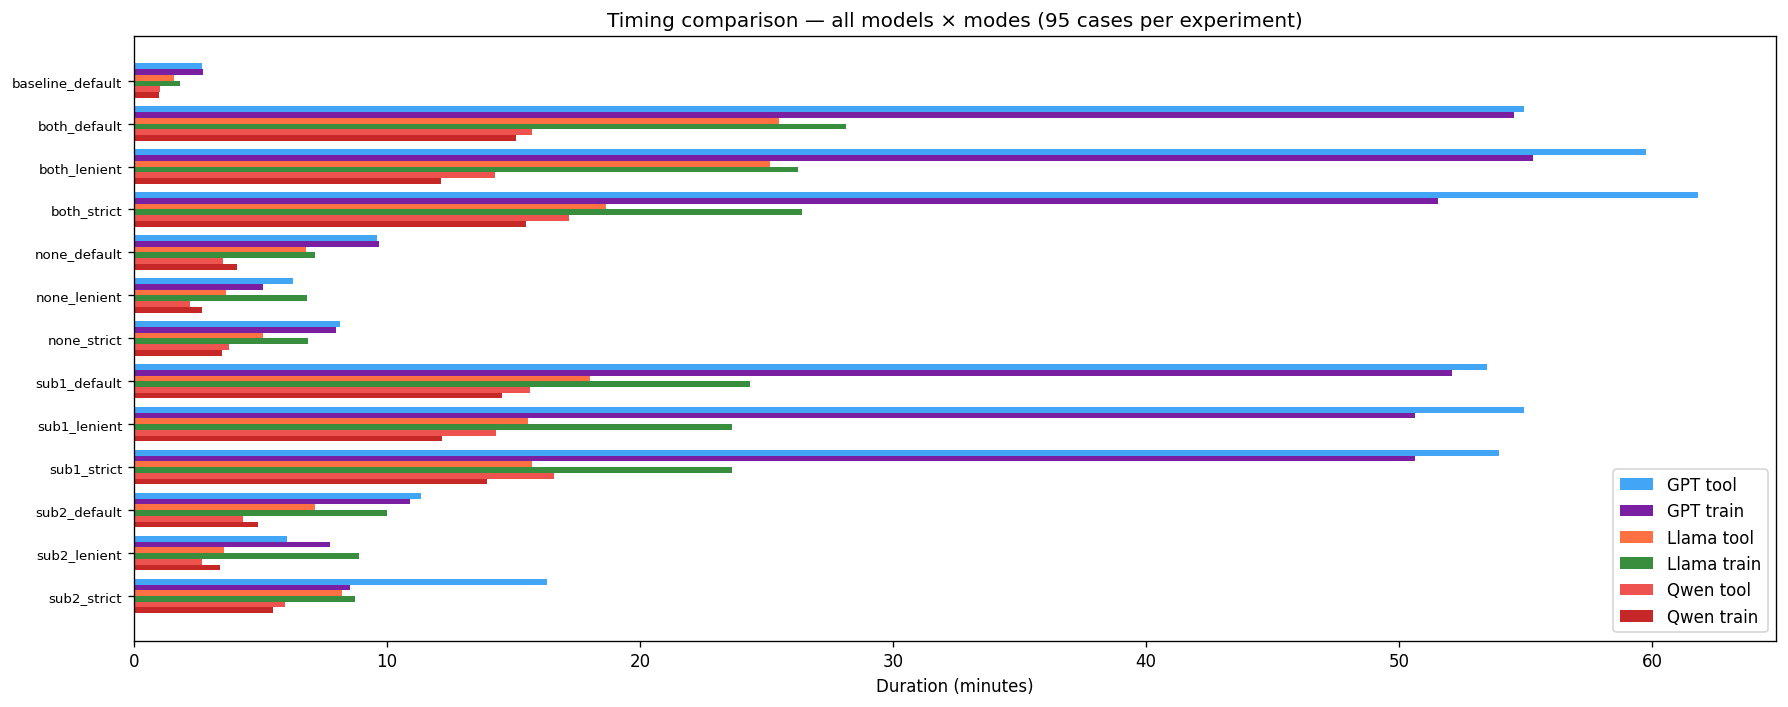


Timing totals (hours):
  GPT tool: 6.7 h  (31 min avg per experiment)
  GPT train: 6.1 h  (28 min avg per experiment)
  Llama tool: 2.6 h  (12 min avg per experiment)
  Llama train: 3.4 h  (16 min avg per experiment)
  Qwen tool: 2.0 h  (9 min avg per experiment)
  Qwen train: 1.8 h  (8 min avg per experiment)


In [35]:
all_timing_frames = []
for model, dirs in MODELS.items():
    for src_label, src_dir in dirs.items():
        if not src_dir or not os.path.isdir(src_dir): continue
        path = os.path.join(src_dir, 'timing.csv')
        if not os.path.exists(path): continue
        df = pd.read_csv(path)
        df['model'] = model; df['src'] = src_label
        df['duration_min'] = df['duration_s'] / 60
        df['key'] = df['experiment'].str.replace(r'^(tool_|train_)', '', regex=True)
        all_timing_frames.append(df)

if not all_timing_frames:
    print('No timing data available yet.')
else:
    timing_all = pd.concat(all_timing_frames, ignore_index=True)

    # Bar chart: duration per experiment, grouped by model+src
    fig, ax = plt.subplots(figsize=(15, 6))
    combos = timing_all[['model','src']].drop_duplicates().values.tolist()
    common_keys = sorted(timing_all['key'].unique())
    n_combos = len(combos); w = 0.8 / n_combos
    x = np.arange(len(common_keys))
    for i, (model, src) in enumerate(combos):
        sub = timing_all[(timing_all['model']==model) & (timing_all['src']==src)]
        sub = sub.set_index('key')
        vals = [sub.loc[k, 'duration_min'] if k in sub.index else 0 for k in common_keys]
        color = COMBO_COLORS.get((model, src), '#aaa')
        ax.barh(x - (n_combos-1)*w/2 + i*w, vals, w,
                label=f'{model} {src}', color=color)
    ax.set_yticks(x); ax.set_yticklabels(common_keys, fontsize=8)
    ax.set_xlabel('Duration (minutes)')
    ax.set_title('Timing comparison — all models × modes (95 cases per experiment)')
    ax.legend(); ax.invert_yaxis()
    plt.tight_layout(); plt.show()

    # Summary
    print('\nTiming totals (hours):')
    for (model, src), grp in timing_all.groupby(['model','src']):
        print(f'  {model} {src}: {grp["duration_s"].sum()/3600:.1f} h  '
              f'({grp["duration_s"].mean()/60:.0f} min avg per experiment)')

## 12. Hardest Cases — Resistant to Both Modes

Cases that are wrong in **both** tool and train across the majority of configs point to fundamental ADM/data issues rather than prompt quality.

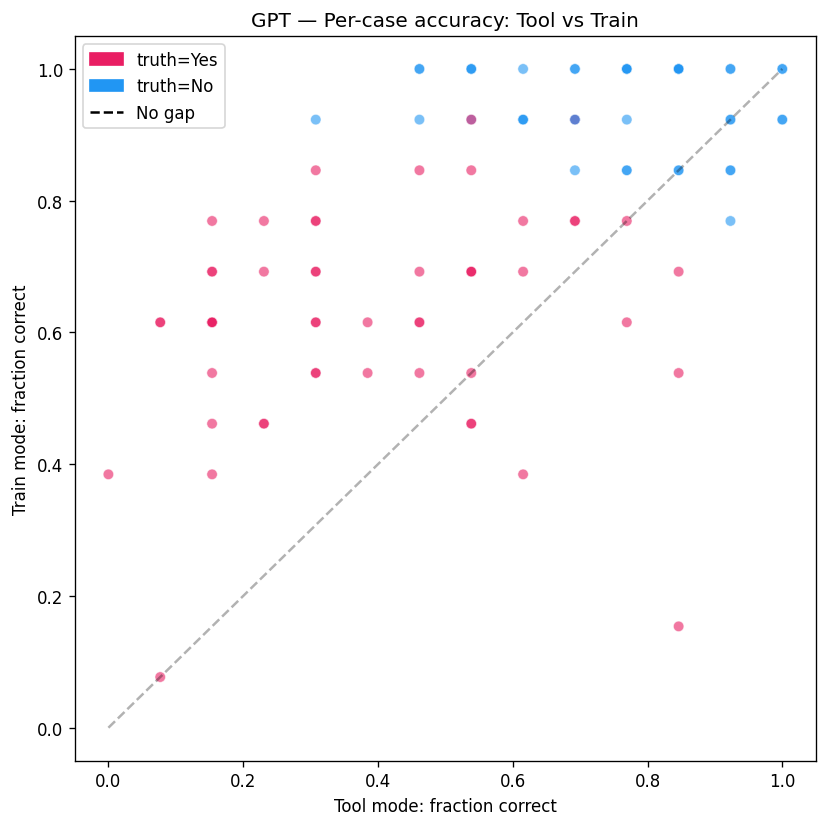

GPT: 0 cases wrong in ALL experiments
Top hardest (≤15% correct):


,case,truth,tool_frac,train_frac,gap
78,T212310,Yes,8%,8%,+0%


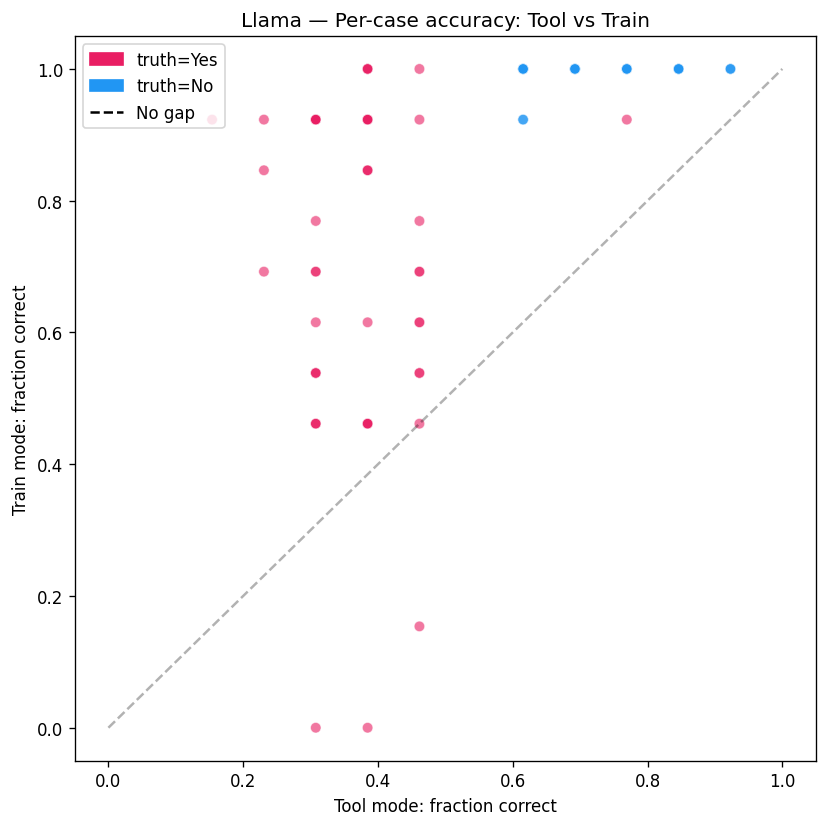

Llama: 0 cases wrong in ALL experiments
Top hardest (≤15% correct):


,case,truth,tool_frac,train_frac,gap


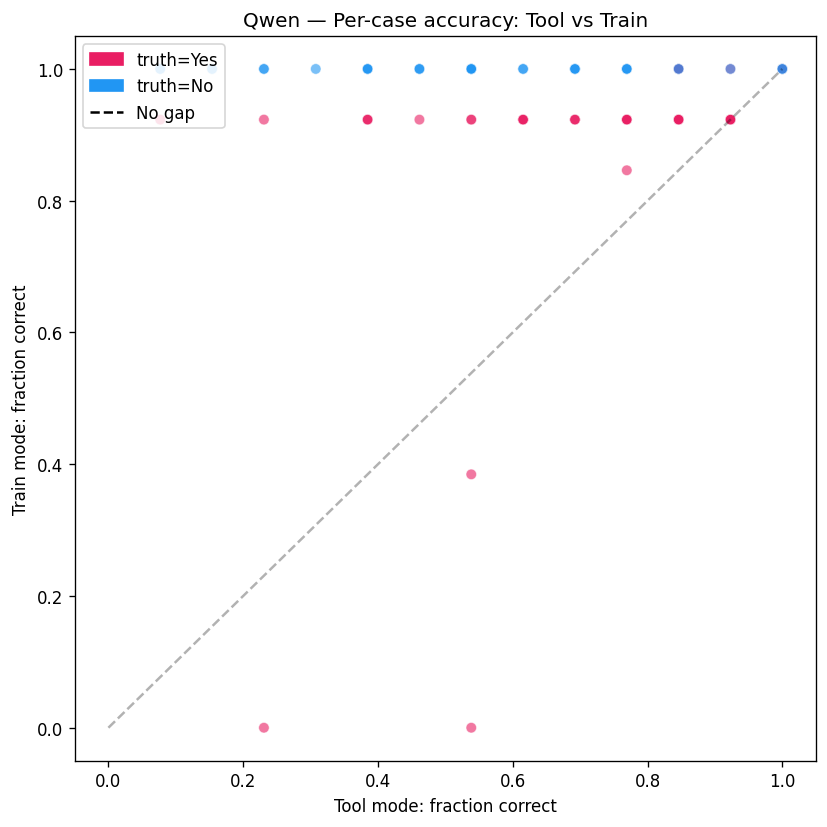

Qwen: 0 cases wrong in ALL experiments
Top hardest (≤15% correct):


,case,truth,tool_frac,train_frac,gap
78,T212310,Yes,23%,0%,-23%


In [36]:
for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p:
        print(f'{model}: no tool data yet'); continue

    t_correct = {c: 0 for c in train_cases}; t_total = {c: 0 for c in train_cases}
    r_correct = {c: 0 for c in train_cases}; r_total  = {c: 0 for c in train_cases}
    for preds in tool_p.values():
        for cid, p in preds.items():
            if cid in gt_train and gt_train[cid] != 'MISSING' and p in ('Yes','No'):
                t_total[cid] += 1
                if p == gt_train[cid]: t_correct[cid] += 1
    for preds in (train_p or {}).values():
        for cid, p in preds.items():
            if cid in gt_train and gt_train[cid] != 'MISSING' and p in ('Yes','No'):
                r_total[cid] += 1
                if p == gt_train[cid]: r_correct[cid] += 1

    hard_rows = []
    for c in train_cases:
        tf = t_correct[c]/t_total[c] if t_total[c] else 0
        rf = r_correct[c]/r_total[c] if r_total[c] else 0
        hard_rows.append({'case': c, 'truth': gt_train[c],
                          'tool_frac': tf, 'train_frac': rf,
                          'both_frac': (tf + rf) / 2 if r_total[c] else tf,
                          'gap': rf - tf})
    hard_df = pd.DataFrame(hard_rows).sort_values('both_frac')

    fig, ax = plt.subplots(figsize=(7, 7))
    colors = ['#E91E63' if t == 'Yes' else '#2196F3' for t in hard_df['truth']]
    ax.scatter(hard_df['tool_frac'], hard_df['train_frac'], c=colors, alpha=0.6, s=40,
               edgecolors='white', lw=0.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.3,label='y=x (no gap)')
    ax.set_xlabel('Tool mode: fraction correct'); ax.set_ylabel('Train mode: fraction correct')
    ax.set_title(f'{model} — Per-case accuracy: Tool vs Train')
    ax.legend([Patch(color='#E91E63'), Patch(color='#2196F3'),
               plt.Line2D([],[], color='k', ls='--')],
              ['truth=Yes','truth=No','No gap'], loc='upper left')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    plt.tight_layout(); plt.show()

    always_wrong = hard_df[hard_df['both_frac'] == 0]
    print(f'{model}: {len(always_wrong)} cases wrong in ALL experiments')
    mostly_wrong = hard_df[hard_df['both_frac'] <= 0.15].head(15)
    print(f'Top hardest (≤15% correct):')
    display(mostly_wrong[['case','truth','tool_frac','train_frac','gap']].style.format(
        {'tool_frac':'{:.0%}','train_frac':'{:.0%}','gap':'{:+.0%}'}
    ).background_gradient(subset=['gap'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

## 13. Summary & Diagnosis (per model)

In [37]:
print('='*70)
print('LLM COMPARISON SUMMARY — TOOL vs TRAIN MODE')
print('='*70)
print(f'\nDataset: {len(train_cases)} TRAIN cases ({yes_count} Yes / {no_count} No)')
print(f'Majority-class baseline: {max(yes_count, no_count)/len(train_cases):.1%}')

for model in available_models:
    print(f'\n{"─"*60}')
    print(f'  MODEL: {model}')
    print(f'{"─"*60}')
    tool_m  = metrics[(metrics['model']==model) & (metrics['src']=='tool')  & (metrics['run_mode']!='baseline')]
    train_m = metrics[(metrics['model']==model) & (metrics['src']=='train') & (metrics['run_mode']!='baseline')]
    bl_m    = metrics[(metrics['model']==model) & (metrics['run_mode']=='baseline')]

    if len(tool_m):
        print(f'  Tool  ({len(tool_m)} configs): '
              f'F1={tool_m["f1"].mean():.3f}  Acc={tool_m["accuracy"].mean():.1%}  '
              f'Prec={tool_m["precision"].mean():.2f}  Rec={tool_m["recall"].mean():.2f}')
    else:
        print(f'  Tool: no data')
    if len(train_m):
        print(f'  Train ({len(train_m)} configs): '
              f'F1={train_m["f1"].mean():.3f}  Acc={train_m["accuracy"].mean():.1%}  '
              f'Prec={train_m["precision"].mean():.2f}  Rec={train_m["recall"].mean():.2f}')
    else:
        print(f'  Train: no data yet')
    if len(bl_m):
        b = bl_m.iloc[0]
        print(f'  Baseline:           '
              f'F1={b["f1"]:.3f}  Acc={b["accuracy"]:.1%}  '
              f'Prec={b["precision"]:.2f}  Rec={b["recall"]:.2f}')

    if len(tool_m) and len(train_m):
        δf1  = train_m['f1'].mean()       - tool_m['f1'].mean()
        δacc = train_m['accuracy'].mean() - tool_m['accuracy'].mean()
        print(f'  Mean Δ (train−tool): ΔF1={δf1:+.3f}  ΔAcc={δacc:+.1%}')

    if len(tool_m):
        best_t = tool_m.sort_values('f1', ascending=False).iloc[0]
        print(f'  Best tool:  {best_t["experiment"]}  F1={best_t["f1"]:.2f}')
    if len(train_m):
        best_r = train_m.sort_values('f1', ascending=False).iloc[0]
        print(f'  Best train: {best_r["experiment"]}  F1={best_r["f1"]:.2f}')

    fn = total_fn_by_model.get(model, 0); fp = total_fp_by_model.get(model, 0)
    if fn + fp > 0:
        print(f'  Gap errors: {fn} FN (conservative) / {fp} FP (generous) — '
              f'{fn/(fn+fp):.0%} conservative')

# ── Cross-model comparison table ─────────────────────────────────────────────
print(f'\n{"─"*60}')
print('  CROSS-MODEL TOOL COMPARISON (avg F1 across 12 non-baseline configs)')
print(f'{"─"*60}')
for model in available_models:
    tool_m = metrics[(metrics['model']==model) & (metrics['src']=='tool') & (metrics['run_mode']!='baseline')]
    if len(tool_m):
        print(f'  {model:10s}: F1={tool_m["f1"].mean():.3f}  '
              f'best={tool_m.sort_values("f1",ascending=False).iloc[0]["experiment"]}  '
              f'F1={tool_m.sort_values("f1",ascending=False).iloc[0]["f1"]:.2f}')

LLM COMPARISON SUMMARY — TOOL vs TRAIN MODE

Dataset: 95 TRAIN cases (53 Yes / 42 No)
Majority-class baseline: 55.8%

────────────────────────────────────────────────────────────
  MODEL: GPT
────────────────────────────────────────────────────────────
  Tool  (12 configs): F1=0.453  Acc=54.7%  Prec=0.67  Rec=0.39
  Train (12 configs): F1=0.743  Acc=77.7%  Prec=0.94  Rec=0.64
  Baseline:           F1=0.513  Acc=60.0%  Prec=0.80  Rec=0.38
  Mean Δ (train−tool): ΔF1=+0.291  ΔAcc=+23.0%
  Best tool:  tool_sub1_lenient  F1=0.73
  Best train: train_both_default  F1=0.95
  Gap errors: 211 FN (conservative) / 123 FP (generous) — 63% conservative

────────────────────────────────────────────────────────────
  MODEL: Llama
────────────────────────────────────────────────────────────
  Tool  (12 configs): F1=0.311  Acc=51.7%  Prec=0.67  Rec=0.36
  Train (12 configs): F1=0.851  Acc=86.6%  Prec=1.00  Rec=0.76
  Baseline:           F1=0.627  Acc=67.4%  Prec=0.87  Rec=0.49
  Mean Δ (train−tool): ΔF1

## 14. Best Model Overall

Which model performs best in **tool-only** mode, and which in **tool + train** combined?  
Metrics averaged across all 12 non-baseline ADM configs (4 configs × 3 question types).

TOOL-ONLY — average across 12 ADM configs (↓ ranked by mean F1)


,f1_mean,f1_max,accuracy_mean,accuracy_max,precision_mean,precision_max,recall_mean,recall_max
model,,,,,,,,
Qwen,0.760,0.829,0.722,0.800,0.737,0.857,0.797,0.943
GPT,0.453,0.729,0.547,0.653,0.670,0.909,0.395,0.887
Llama,0.311,0.750,0.517,0.642,0.672,1.000,0.358,0.962



TOOL + TRAIN COMBINED — ranked by mean F1 across both modes


,tool_f1_mean,train_f1_mean,combined_f1,tool_acc_mean,train_acc_mean,combined_acc,best_tool_f1,best_train_f1
model,,,,,,,,
Qwen,0.760,0.974,0.867,0.722,0.972,0.847,0.829,0.981
GPT,0.453,0.743,0.598,0.547,0.777,0.662,0.729,0.950
Llama,0.311,0.851,0.581,0.517,0.866,0.691,0.750,0.971


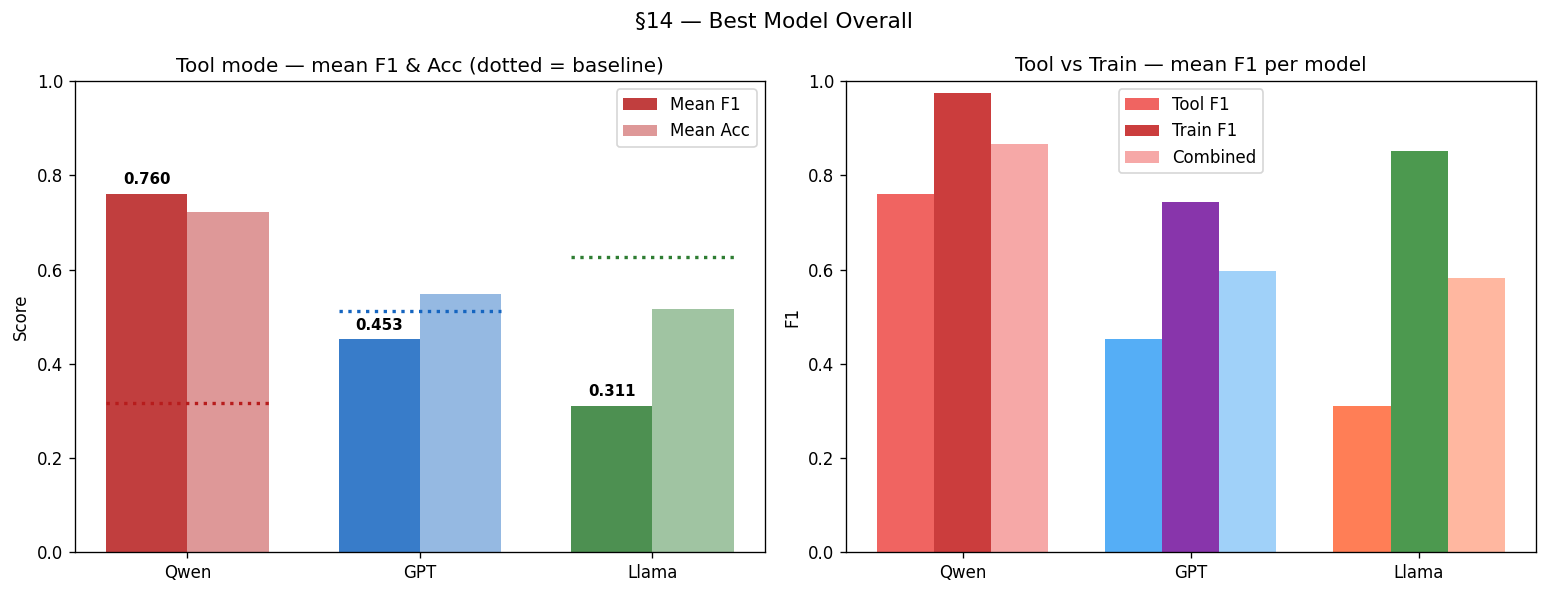

In [38]:
non_bl = metrics[metrics['run_mode'] != 'baseline'].copy()
bl_rows = metrics[metrics['run_mode'] == 'baseline'].copy()

# ── 14a. Tool-only ranking ────────────────────────────────────────────────────
tool_summary = (
    non_bl[non_bl['src'] == 'tool']
    .groupby('model')[['f1', 'accuracy', 'precision', 'recall']]
    .agg(['mean', 'max'])
)
tool_summary.columns = ['_'.join(c) for c in tool_summary.columns]
tool_summary = tool_summary.sort_values('f1_mean', ascending=False)

print('TOOL-ONLY — average across 12 ADM configs (↓ ranked by mean F1)')
display(tool_summary.style.format('{:.3f}').background_gradient(
    subset=['f1_mean', 'f1_max', 'accuracy_mean'], cmap='RdYlGn', vmin=0.3, vmax=0.8
))

# ── 14b. Tool+Train combined ranking (mean of tool avg and train avg) ─────────
train_summary = (
    non_bl[non_bl['src'] == 'train']
    .groupby('model')[['f1', 'accuracy', 'precision', 'recall']]
    .agg(['mean', 'max'])
)
train_summary.columns = ['_'.join(c) for c in train_summary.columns]

combined_models = sorted(set(tool_summary.index) & set(train_summary.index))
combined_rows = []
for m in combined_models:
    tool_f1_mean  = tool_summary.loc[m,  'f1_mean']
    train_f1_mean = train_summary.loc[m, 'f1_mean']
    tool_acc_mean  = tool_summary.loc[m,  'accuracy_mean']
    train_acc_mean = train_summary.loc[m, 'accuracy_mean']
    combined_rows.append({
        'model': m,
        'tool_f1_mean':   tool_f1_mean,
        'train_f1_mean':  train_f1_mean,
        'combined_f1':    (tool_f1_mean + train_f1_mean) / 2,
        'tool_acc_mean':  tool_acc_mean,
        'train_acc_mean': train_acc_mean,
        'combined_acc':   (tool_acc_mean + train_acc_mean) / 2,
        'best_tool_f1':   tool_summary.loc[m,  'f1_max'],
        'best_train_f1':  train_summary.loc[m, 'f1_max'],
    })
combined_df = pd.DataFrame(combined_rows).set_index('model').sort_values('combined_f1', ascending=False)

print('\nTOOL + TRAIN COMBINED — ranked by mean F1 across both modes')
display(combined_df.style.format('{:.3f}').background_gradient(
    subset=['combined_f1', 'combined_acc'], cmap='RdYlGn', vmin=0.3, vmax=0.8
))

# ── 14c. Visual comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_sorted_tool  = tool_summary.index.tolist()
models_sorted_combo = combined_df.index.tolist()

# Tool-only
ax = axes[0]
x = np.arange(len(models_sorted_tool)); w = 0.35
ax.bar(x - w/2, tool_summary.loc[models_sorted_tool, 'f1_mean'],   w,
       label='Mean F1',  color=[MODEL_COLORS.get(m,'#aaa') for m in models_sorted_tool], alpha=0.85)
ax.bar(x + w/2, tool_summary.loc[models_sorted_tool, 'accuracy_mean'], w,
       label='Mean Acc', color=[MODEL_COLORS.get(m,'#aaa') for m in models_sorted_tool], alpha=0.45)
# baseline ref
for i, m in enumerate(models_sorted_tool):
    bl = bl_rows[bl_rows['model'] == m]
    if len(bl):
        ax.plot([i - w, i + w], [bl.iloc[0]['f1']] * 2, color=MODEL_COLORS.get(m,'#aaa'),
                ls=':', lw=2)
ax.set_xticks(x); ax.set_xticklabels(models_sorted_tool)
ax.set_ylim(0, 1); ax.set_title('Tool mode — mean F1 & Acc (dotted = baseline)')
ax.set_ylabel('Score'); ax.legend()
for i, m in enumerate(models_sorted_tool):
    ax.text(i - w/2, tool_summary.loc[m, 'f1_mean'] + 0.02,
            f'{tool_summary.loc[m, "f1_mean"]:.3f}', ha='center', fontsize=9, fontweight='bold')

# Combined
ax = axes[1]
x = np.arange(len(models_sorted_combo)); w = 0.25
for j, (col, label, alpha) in enumerate([
    ('tool_f1_mean',  'Tool F1',  0.9),
    ('train_f1_mean', 'Train F1', 0.9),
    ('combined_f1',   'Combined', 0.5),
]):
    ax.bar(x + (j-1)*w, combined_df.loc[models_sorted_combo, col], w,
           label=label,
           color=[COMBO_COLORS.get((m, ['tool','train','tool'][j]), '#aaa')
                  for m in models_sorted_combo],
           alpha=alpha)
ax.set_xticks(x); ax.set_xticklabels(models_sorted_combo)
ax.set_ylim(0, 1); ax.set_title('Tool vs Train — mean F1 per model')
ax.set_ylabel('F1'); ax.legend()
plt.suptitle('§14 — Best Model Overall', fontsize=13)
plt.tight_layout(); plt.show()


## 15. Smallest Tool↔Train Delta per Model

Which model's tool-mode performance is closest to its train-mode performance?  
A small delta means the model can already navigate the ADM well without oracle guidance.  
A large delta means it relies heavily on the decision reasoning to get the right answer.

TOOL↔TRAIN DELTA — ranked by absolute mean F1 delta (smallest = most self-sufficient)


,mean_delta_f1,abs_mean_delta_f1,mean_delta_acc,min_delta_f1,max_delta_f1,configs_improved,configs_degraded
model,,,,,,,
Qwen,+0.214,0.214,+0.250,+0.152,+0.270,12,0
GPT,+0.291,0.291,+0.230,+0.139,+0.530,12,0
Llama,+0.540,0.544,+0.349,-0.026,+0.898,10,1


/tmp/ipykernel_1561482/3888870818.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=model_order, patch_artist=True, widths=0.4)


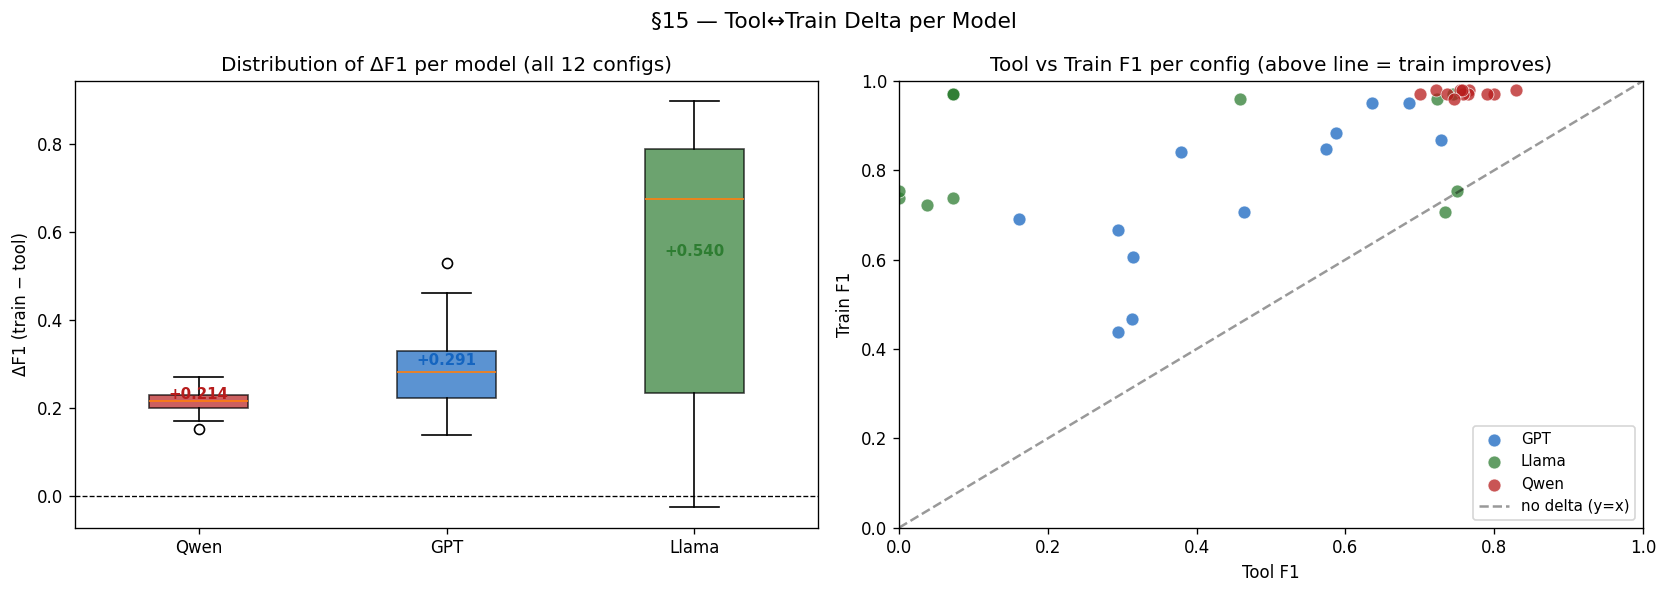


Per-config ΔF1 ranked (best → worst) within each model:

  GPT:
    none_strict                   +█████████████████████  ΔF1=+0.530  (tool=0.16 → train=0.69)
    both_lenient                  +██████████████████  ΔF1=+0.462  (tool=0.38 → train=0.84)
    sub1_strict                   +██████████████    ΔF1=+0.373  (tool=0.29 → train=0.67)
    both_default                  +████████████      ΔF1=+0.314  (tool=0.64 → train=0.95)
    none_default                  +███████████       ΔF1=+0.297  (tool=0.59 → train=0.88)
    sub2_strict                   +███████████       ΔF1=+0.291  (tool=0.31 → train=0.61)
    sub2_default                  +██████████        ΔF1=+0.273  (tool=0.57 → train=0.85)
    sub1_default                  +██████████        ΔF1=+0.265  (tool=0.69 → train=0.95)
    both_strict                   +█████████         ΔF1=+0.244  (tool=0.46 → train=0.71)
    sub2_lenient                  +██████            ΔF1=+0.155  (tool=0.31 → train=0.47)
    none_lenient            

In [39]:
# ── Per-config deltas for every model ────────────────────────────────────────
all_delta_rows = []
for model in available_models:
    tool_m  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
    train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
    for k in sorted(set(tool_m.index) & set(train_m.index)):
        all_delta_rows.append({
            'model': model, 'config': k,
            'adm_config': tool_m.loc[k, 'adm_config'],
            'questions':  tool_m.loc[k, 'questions'],
            'tool_f1':    tool_m.loc[k, 'f1'],
            'train_f1':   train_m.loc[k, 'f1'],
            'delta_f1':   train_m.loc[k, 'f1']  - tool_m.loc[k, 'f1'],
            'tool_acc':   tool_m.loc[k, 'accuracy'],
            'train_acc':  train_m.loc[k, 'accuracy'],
            'delta_acc':  train_m.loc[k, 'accuracy'] - tool_m.loc[k, 'accuracy'],
            'abs_delta_f1': abs(train_m.loc[k, 'f1'] - tool_m.loc[k, 'f1']),
        })
all_deltas = pd.DataFrame(all_delta_rows)

# ── Summary table — mean and abs-mean delta per model ────────────────────────
delta_summary = all_deltas.groupby('model').agg(
    mean_delta_f1   = ('delta_f1',     'mean'),
    abs_mean_delta_f1 = ('abs_delta_f1', 'mean'),
    mean_delta_acc  = ('delta_acc',    'mean'),
    min_delta_f1    = ('delta_f1',     'min'),
    max_delta_f1    = ('delta_f1',     'max'),
    configs_improved = ('delta_f1',    lambda x: (x > 0.005).sum()),
    configs_degraded = ('delta_f1',    lambda x: (x < -0.005).sum()),
).sort_values('abs_mean_delta_f1')

print('TOOL↔TRAIN DELTA — ranked by absolute mean F1 delta (smallest = most self-sufficient)')
display(delta_summary.style.format({
    'mean_delta_f1':'{:+.3f}', 'abs_mean_delta_f1':'{:.3f}',
    'mean_delta_acc':'{:+.3f}', 'min_delta_f1':'{:+.3f}', 'max_delta_f1':'{:+.3f}',
}).background_gradient(subset=['abs_mean_delta_f1'], cmap='RdYlGn_r', vmin=0, vmax=0.2))

# ── Per-config delta distribution per model ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of per-config ΔF1 by model
ax = axes[0]
model_order = delta_summary.index.tolist()  # sorted by abs delta
data_for_box = [all_deltas[all_deltas['model']==m]['delta_f1'].values for m in model_order]
bp = ax.boxplot(data_for_box, labels=model_order, patch_artist=True, widths=0.4)
for patch, m in zip(bp['boxes'], model_order):
    patch.set_facecolor(MODEL_COLORS.get(m, '#aaa')); patch.set_alpha(0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('ΔF1 (train − tool)')
ax.set_title('Distribution of ΔF1 per model (all 12 configs)')
for i, m in enumerate(model_order):
    mu = all_deltas[all_deltas['model']==m]['delta_f1'].mean()
    ax.text(i+1, mu, f'{mu:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=MODEL_COLORS.get(m,'#333'))

# Scatter: tool F1 vs train F1 per config, coloured by model
ax = axes[1]
for m in available_models:
    sub = all_deltas[all_deltas['model']==m]
    ax.scatter(sub['tool_f1'], sub['train_f1'],
               color=MODEL_COLORS.get(m,'#aaa'), label=m, alpha=0.75, s=60,
               edgecolors='white', lw=0.5)
lim_min = max(0, all_deltas[['tool_f1','train_f1']].min().min() - 0.05)
lim_max = min(1, all_deltas[['tool_f1','train_f1']].max().max() + 0.05)
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='no delta (y=x)')
ax.set_xlabel('Tool F1'); ax.set_ylabel('Train F1')
ax.set_title('Tool vs Train F1 per config (above line = train improves)')
ax.legend(fontsize=9)
ax.set_xlim(lim_min, lim_max); ax.set_ylim(lim_min, lim_max)

plt.suptitle('§15 — Tool↔Train Delta per Model', fontsize=13)
plt.tight_layout(); plt.show()

# ── Ranked listing of configs by delta within each model ─────────────────────
print('\nPer-config ΔF1 ranked (best → worst) within each model:')
for m in available_models:
    sub = all_deltas[all_deltas['model']==m].sort_values('delta_f1', ascending=False)
    print(f'\n  {m}:')
    for _, row in sub.iterrows():
        bar = '█' * int(abs(row['delta_f1']) * 40)
        sign = '+' if row['delta_f1'] >= 0 else '-'
        print(f"    {row['config']:28s}  {sign}{bar:<16}  ΔF1={row['delta_f1']:+.3f}  "
              f"(tool={row['tool_f1']:.2f} → train={row['train_f1']:.2f})")


## 16. Best Question Format Across Models

Does framing questions as `default` / `lenient` / `strict` systematically affect performance?  
Averaged across all models and ADM configs (excluding baseline).

QUESTION FORMAT — overall performance (all models × all ADM configs × tool+train)



,f1_mean,f1_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
questions,,,,,,,,
default,0.812,0.133,0.786,0.153,0.837,0.174,0.816,0.157
lenient,0.636,0.322,0.711,0.192,0.772,0.279,0.608,0.357
strict,0.599,0.329,0.704,0.192,0.898,0.153,0.527,0.337



Mean F1 by model × question type:


questions,default,lenient,strict
model,,,
GPT,0.765,0.541,0.488
Llama,0.793,0.494,0.457
Qwen,0.879,0.872,0.851



Mean F1 by mode × question type:


questions,default,lenient,strict
src,,,
tool,0.712,0.445,0.368
train,0.912,0.827,0.830


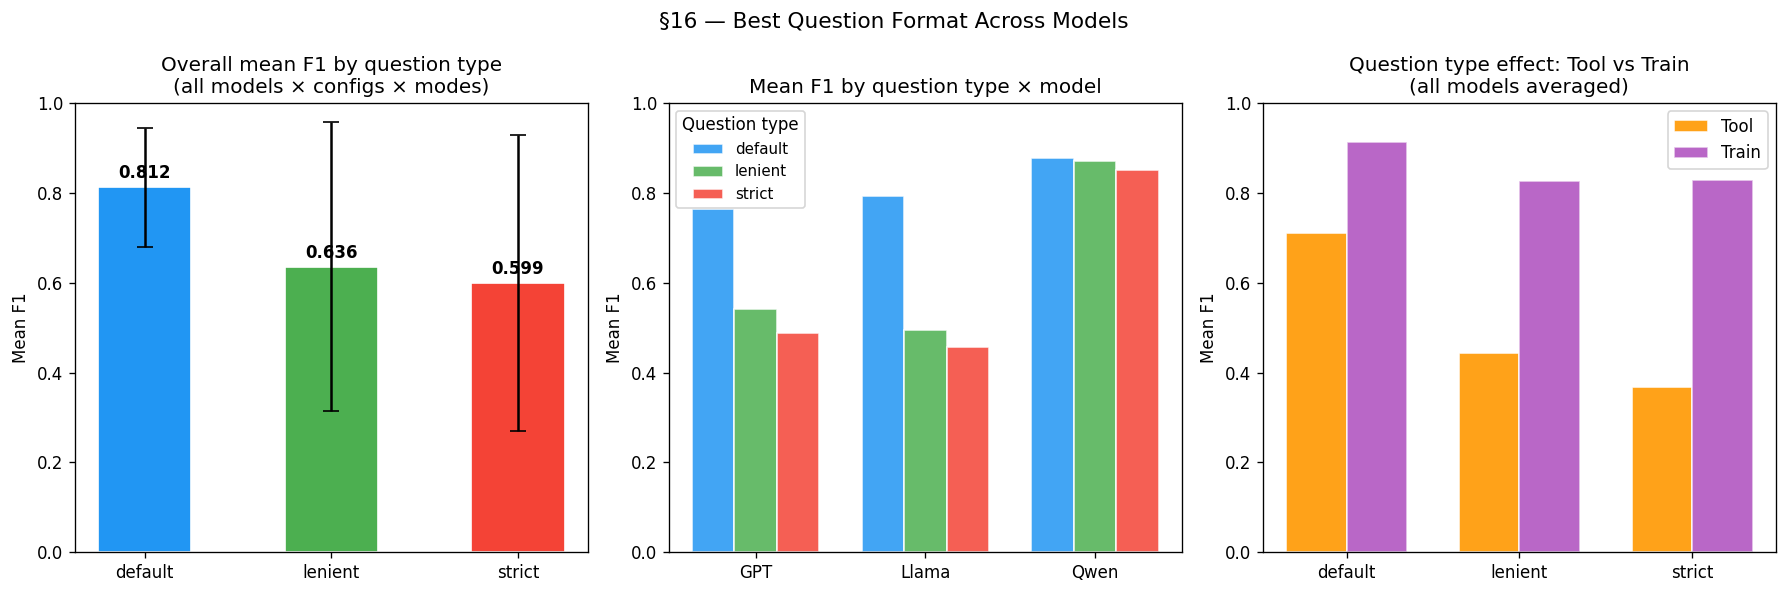


Question type ranking within each (model, mode) group:


,model,src,1st,2nd,3rd,best_f1
0,GPT,tool,default,lenient,strict,0.621
1,GPT,train,default,strict,lenient,0.908
2,Llama,tool,default,lenient,strict,0.738
3,Llama,train,lenient,strict,default,0.856
4,Qwen,tool,default,lenient,strict,0.777
5,Qwen,train,default,lenient,strict,0.981



Question format wins (top rank count across all model×mode groups):
  default: 5 wins out of 6 groups
  lenient: 1 wins out of 6 groups


In [40]:
q_non_bl = non_bl.copy()  # already excludes baseline (which has no meaningful q-type)

# ── Overall: mean F1 / Acc by question type (all models, both modes) ─────────
q_overall = (
    q_non_bl.groupby('questions')[['f1', 'accuracy', 'precision', 'recall']]
    .agg(['mean', 'std'])
)
q_overall.columns = ['_'.join(c) for c in q_overall.columns]
q_overall = q_overall.sort_values('f1_mean', ascending=False)

print('QUESTION FORMAT — overall performance (all models × all ADM configs × tool+train)')
display(q_overall.style.format('{:.3f}').background_gradient(
    subset=['f1_mean', 'accuracy_mean'], cmap='RdYlGn', vmin=0.3, vmax=0.8
))

# ── By model × question type ──────────────────────────────────────────────────
q_by_model = (
    q_non_bl.groupby(['model', 'questions'])[['f1', 'accuracy']]
    .mean().round(3).unstack('questions')
)
print('\nMean F1 by model × question type:')
display(q_by_model['f1'].style.format('{:.3f}').background_gradient(
    cmap='RdYlGn', vmin=0.3, vmax=0.8, axis=None
))

# ── By mode (tool vs train) × question type ───────────────────────────────────
q_by_mode = (
    q_non_bl.groupby(['src', 'questions'])[['f1', 'accuracy']]
    .mean().round(3).unstack('questions')
)
print('\nMean F1 by mode × question type:')
display(q_by_mode['f1'].style.format('{:.3f}').background_gradient(
    cmap='RdYlGn', vmin=0.3, vmax=0.8, axis=None
))

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
q_types  = ['default', 'lenient', 'strict']
q_colors_list = [Q_COLORS[q] for q in q_types]

# Panel 1: overall mean F1 by question type
ax = axes[0]
vals = [q_overall.loc[q, 'f1_mean'] if q in q_overall.index else 0 for q in q_types]
errs = [q_overall.loc[q, 'f1_std']  if q in q_overall.index else 0 for q in q_types]
bars = ax.bar(q_types, vals, color=q_colors_list, edgecolor='white', width=0.5)
ax.errorbar(q_types, vals, yerr=errs, fmt='none', color='black', capsize=5, lw=1.5)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('Overall mean F1 by question type\n(all models × configs × modes)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')

# Panel 2: per-model breakdown — grouped bar (question type within model)
ax = axes[1]
model_list = sorted(q_non_bl['model'].unique())
x = np.arange(len(model_list)); w = 0.25
for j, (q, c) in enumerate(zip(q_types, q_colors_list)):
    vals_m = []
    for m in model_list:
        sub = q_non_bl[(q_non_bl['model']==m) & (q_non_bl['questions']==q)]
        vals_m.append(sub['f1'].mean() if len(sub) else 0)
    ax.bar(x + (j-1)*w, vals_m, w, label=q, color=c, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(model_list)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('Mean F1 by question type × model')
ax.legend(title='Question type', fontsize=9)

# Panel 3: tool vs train — question type effect
ax = axes[2]
x = np.arange(len(q_types)); w = 0.35
for j, (src, label, alpha) in enumerate([('tool','Tool',0.9),('train','Train',0.7)]):
    vals_s = []
    for q in q_types:
        sub = q_non_bl[(q_non_bl['src']==src) & (q_non_bl['questions']==q)]
        vals_s.append(sub['f1'].mean() if len(sub) else 0)
    color = '#FF9800' if src == 'tool' else '#9C27B0'
    ax.bar(x + (j-0.5)*w, vals_s, w, label=label, color=color, alpha=alpha, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(q_types)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('Question type effect: Tool vs Train\n(all models averaged)')
ax.legend()

plt.suptitle('§16 — Best Question Format Across Models', fontsize=13)
plt.tight_layout(); plt.show()

# ── Win table: how often does each question type rank #1 per model+mode? ──────
print('\nQuestion type ranking within each (model, mode) group:')
rank_rows = []
for (model, src), grp in q_non_bl.groupby(['model', 'src']):
    q_means = grp.groupby('questions')['f1'].mean().sort_values(ascending=False)
    rank_rows.append({'model': model, 'src': src,
                      '1st': q_means.index[0] if len(q_means) > 0 else '-',
                      '2nd': q_means.index[1] if len(q_means) > 1 else '-',
                      '3rd': q_means.index[2] if len(q_means) > 2 else '-',
                      'best_f1': q_means.iloc[0] if len(q_means) > 0 else 0})
rank_df = pd.DataFrame(rank_rows).sort_values(['model','src'])
display(rank_df.style.format({'best_f1': '{:.3f}'}))

from collections import Counter
wins = Counter(r['1st'] for r in rank_rows)
print(f'\nQuestion format wins (top rank count across all model×mode groups):')
for q, cnt in sorted(wins.items(), key=lambda x: -x[1]):
    print(f'  {q}: {cnt} wins out of {len(rank_rows)} groups')


## 17. Best ADM Config Across Models

Which ADM configuration (`both` / `sub_adm_1` / `sub_adm_2` / `none`) delivers the best performance?  
Averaged across all models, question types, and both modes (tool + train).

ADM CONFIG — overall performance (all models × all question types × tool+train)


,f1_mean,f1_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
adm_config,,,,,,,,
both,0.726,0.297,0.765,0.196,0.869,0.163,0.712,0.324
sub1,0.750,0.256,0.767,0.183,0.841,0.167,0.747,0.287
sub2,0.627,0.294,0.700,0.170,0.820,0.255,0.572,0.316
none,0.625,0.306,0.702,0.179,0.813,0.259,0.570,0.327



Mean F1 by model × ADM config:


,both,sub1,sub2,none
model,,,,
GPT,0.663,0.699,0.520,0.509
Llama,0.634,0.691,0.503,0.498
Qwen,0.881,0.861,0.859,0.869



Mean F1 by mode × ADM config:


adm_config,both,none,sub1,sub2
src,,,,
tool,0.524,0.460,0.579,0.470
train,0.927,0.791,0.922,0.785


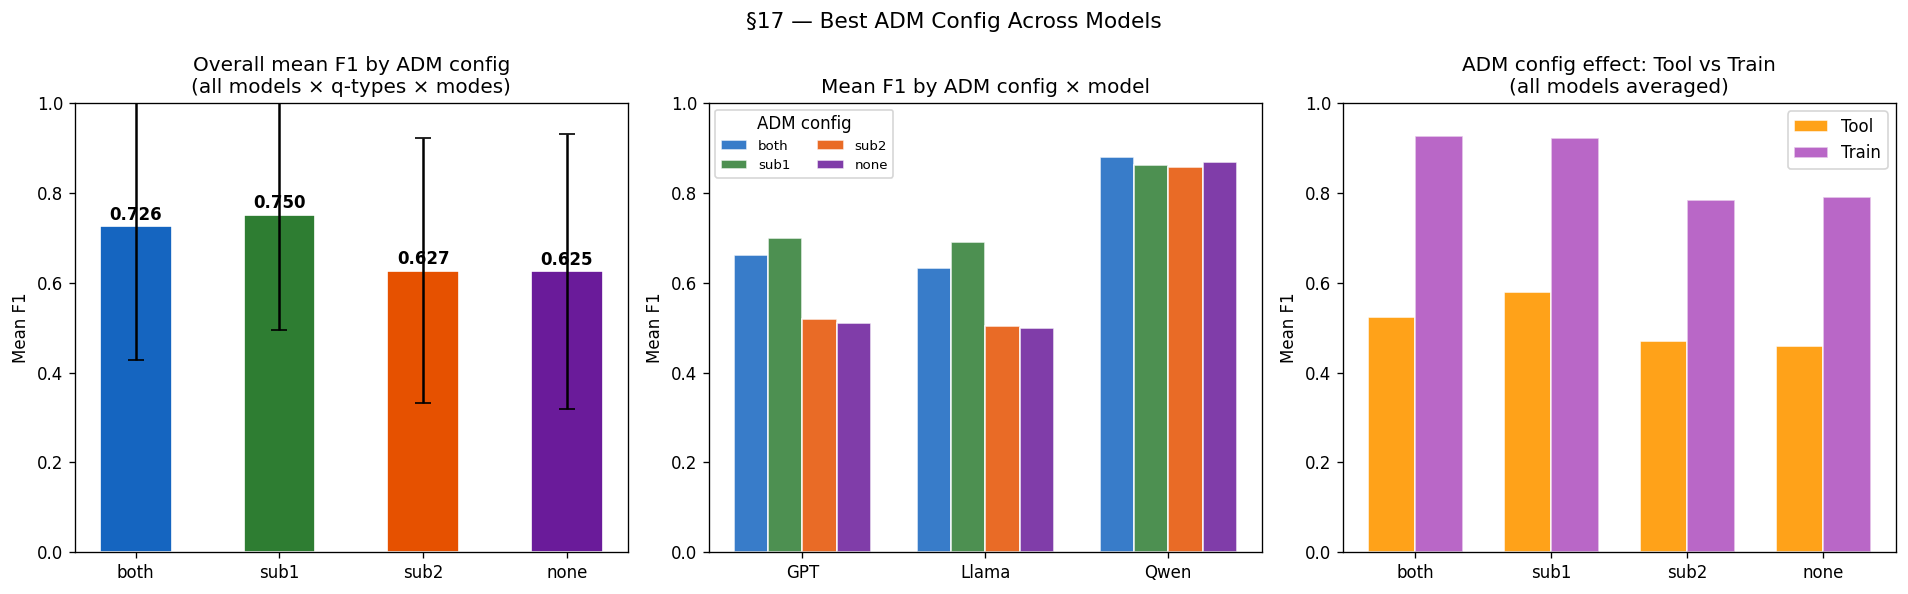


ADM config ranking within each (model, mode) group:


,model,src,1st,2nd,3rd,4th,best_f1
0,GPT,tool,sub1,both,sub2,none,0.570
1,GPT,train,both,sub1,none,sub2,0.833
2,Llama,tool,sub1,both,none,sub2,0.418
3,Llama,train,both,sub1,sub2,none,0.971
4,Qwen,tool,both,none,sub1,sub2,0.784
5,Qwen,train,both,none,sub1,sub2,0.977



ADM config wins (top rank count across all model×mode groups):
  both: 4 wins out of 6 groups
  sub1: 2 wins out of 6 groups


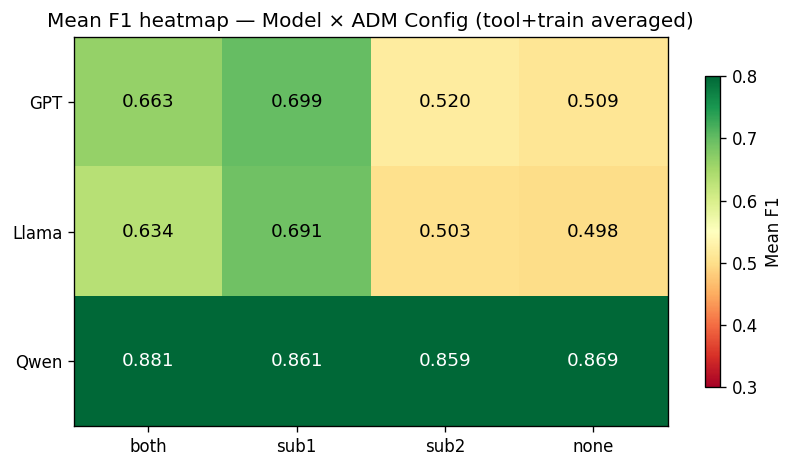

In [43]:
ADM_ORDER = ['both', 'sub1', 'sub2', 'none']
ADM_COLORS = {'both': '#1565C0', 'sub1': '#2E7D32', 'sub2': '#E65100', 'none': '#6A1B9A'}

# ── Overall: mean F1 / Acc by ADM config (all models, both modes) ─────────────
adm_overall = (
    non_bl.groupby('adm_config')[['f1', 'accuracy', 'precision', 'recall']]
    .agg(['mean', 'std'])
)
adm_overall.columns = ['_'.join(c) for c in adm_overall.columns]
adm_overall = adm_overall.reindex([a for a in ADM_ORDER if a in adm_overall.index])

print('ADM CONFIG — overall performance (all models × all question types × tool+train)')
display(adm_overall.style.format('{:.3f}').background_gradient(
    subset=['f1_mean', 'accuracy_mean'], cmap='RdYlGn', vmin=0.3, vmax=0.8
))

# ── By model × ADM config ─────────────────────────────────────────────────────
adm_by_model = (
    non_bl.groupby(['model', 'adm_config'])[['f1', 'accuracy']]
    .mean().round(3).unstack('adm_config')
)
adm_by_model = adm_by_model.reindex(columns=pd.MultiIndex.from_product(
    [['f1', 'accuracy'], [a for a in ADM_ORDER if a in non_bl['adm_config'].unique()]]
))
print('\nMean F1 by model × ADM config:')
display(adm_by_model['f1'].style.format('{:.3f}').background_gradient(
    cmap='RdYlGn', vmin=0.3, vmax=0.8, axis=None
))

# ── By mode (tool vs train) × ADM config ─────────────────────────────────────
adm_by_mode = (
    non_bl.groupby(['src', 'adm_config'])[['f1', 'accuracy']]
    .mean().round(3).unstack('adm_config')
)
print('\nMean F1 by mode × ADM config:')
display(adm_by_mode['f1'].style.format('{:.3f}').background_gradient(
    cmap='RdYlGn', vmin=0.3, vmax=0.8, axis=None
))

# ── Visual ────────────────────────────────────────────────────────────────────
adm_configs_present = [a for a in ADM_ORDER if a in non_bl['adm_config'].unique()]
adm_colors_list = [ADM_COLORS[a] for a in adm_configs_present]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

# Panel 1: overall mean F1 by ADM config
ax = axes[0]
vals = [adm_overall.loc[a, 'f1_mean'] if a in adm_overall.index else 0 for a in adm_configs_present]
errs = [adm_overall.loc[a, 'f1_std']  if a in adm_overall.index else 0 for a in adm_configs_present]
bars = ax.bar(adm_configs_present, vals, color=adm_colors_list, edgecolor='white', width=0.5)
ax.errorbar(adm_configs_present, vals, yerr=errs, fmt='none', color='black', capsize=5, lw=1.5)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('Overall mean F1 by ADM config\n(all models × q-types × modes)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')

# Panel 2: per-model breakdown
ax = axes[1]
model_list = sorted(non_bl['model'].unique())
x = np.arange(len(model_list))
n_adm = len(adm_configs_present); w = 0.75 / n_adm
for j, (adm, c) in enumerate(zip(adm_configs_present, adm_colors_list)):
    vals_m = []
    for m in model_list:
        sub = non_bl[(non_bl['model']==m) & (non_bl['adm_config']==adm)]
        vals_m.append(sub['f1'].mean() if len(sub) else 0)
    offset = (j - (n_adm-1)/2) * w
    ax.bar(x + offset, vals_m, w, label=adm, color=c, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(model_list)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('Mean F1 by ADM config × model')
ax.legend(title='ADM config', fontsize=8, ncol=2)

# Panel 3: tool vs train — ADM config effect
ax = axes[2]
x = np.arange(len(adm_configs_present)); w = 0.35
for j, (src, label, alpha) in enumerate([('tool','Tool',0.9),('train','Train',0.7)]):
    vals_s = []
    for adm in adm_configs_present:
        sub = non_bl[(non_bl['src']==src) & (non_bl['adm_config']==adm)]
        vals_s.append(sub['f1'].mean() if len(sub) else 0)
    color = '#FF9800' if src == 'tool' else '#9C27B0'
    ax.bar(x + (j-0.5)*w, vals_s, w, label=label, color=color, alpha=alpha, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(adm_configs_present)
ax.set_ylim(0, 1); ax.set_ylabel('Mean F1')
ax.set_title('ADM config effect: Tool vs Train\n(all models averaged)')
ax.legend()

plt.suptitle('§17 — Best ADM Config Across Models', fontsize=13)
plt.tight_layout(); plt.show()

# ── Win table: how often does each ADM config rank #1? ───────────────────────
print('\nADM config ranking within each (model, mode) group:')
adm_rank_rows = []
for (model, src), grp in non_bl.groupby(['model', 'src']):
    adm_means = grp.groupby('adm_config')['f1'].mean().sort_values(ascending=False)
    adm_rank_rows.append({'model': model, 'src': src,
                          '1st': adm_means.index[0] if len(adm_means) > 0 else '-',
                          '2nd': adm_means.index[1] if len(adm_means) > 1 else '-',
                          '3rd': adm_means.index[2] if len(adm_means) > 2 else '-',
                          '4th': adm_means.index[3] if len(adm_means) > 3 else '-',
                          'best_f1': adm_means.iloc[0] if len(adm_means) > 0 else 0})
adm_rank_df = pd.DataFrame(adm_rank_rows).sort_values(['model','src'])
display(adm_rank_df.style.format({'best_f1': '{:.3f}'}))

adm_wins = Counter(r['1st'] for r in adm_rank_rows)
print(f'\nADM config wins (top rank count across all model×mode groups):')
for adm, cnt in sorted(adm_wins.items(), key=lambda x: -x[1]):
    print(f'  {adm}: {cnt} wins out of {len(adm_rank_rows)} groups')

# ── Heatmap: model × ADM config — mean F1 (all modes combined) ───────────────
heat_data = non_bl.groupby(['model', 'adm_config'])['f1'].mean().unstack('adm_config')
heat_data = heat_data.reindex(columns=[a for a in ADM_ORDER if a in heat_data.columns])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heat_data.values, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=0.8)
ax.set_xticks(range(len(heat_data.columns))); ax.set_xticklabels(heat_data.columns)
ax.set_yticks(range(len(heat_data.index)));  ax.set_yticklabels(heat_data.index)
plt.colorbar(im, ax=ax, label='Mean F1', shrink=0.8)
for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        val = heat_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=11,
                    color='black' if 0.4 < val < 0.7 else 'white')
ax.set_title('Mean F1 heatmap — Model × ADM Config (tool+train averaged)')
plt.tight_layout(); plt.show()
